## 1. Dataset Loading and Initial Exploration

#### In this section, the code does the following: finds the CBIS-DDSM metadata, loads it into Python, understand what is in it, looks at the pathology classes, and converts pathology into 0 = benign, 1 = malignant. 

In [1]:
#libraries used in this project
from pathlib import Path 
import pandas as pd #used for CSV and dataframes
import matplotlib.pyplot as plt #used in displaying mammographs and the graphs 
from PIL import Image #used to open JPEG images 
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold

#main project folders 
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
CSV_DIR = DATA_DIR / "csv" #CSV folder
JPEG_DIR = DATA_DIR / "jpeg" #JPEG image folder

#paths to CBIS-DDSM files (training and test files)
train_csv = CSV_DIR / "mass_case_description_train_set.csv"
test_csv = CSV_DIR / "mass_case_description_test_set.csv"

In [2]:
#reads the CSV files 
train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

print("Training shape:", train_df.shape) 
print("Test shape:", test_df.shape)

Training shape: (1318, 14)
Test shape: (378, 14)


In [3]:
train_df.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


In [4]:
train_df["pathology"].value_counts()

pathology
MALIGNANT                  637
BENIGN                     577
BENIGN_WITHOUT_CALLBACK    104
Name: count, dtype: int64

In [5]:
test_df["pathology"].value_counts()

pathology
BENIGN                     194
MALIGNANT                  147
BENIGN_WITHOUT_CALLBACK     37
Name: count, dtype: int64

In [6]:
#neural networks need numerical values (0,1)
#converts the pathology labels into two classes the CNN will use (0 and 1)
#0 = benign 
#1 = malignant
label_map = {
    "BENIGN": 0, 
    "BENIGN_WITHOUT_CALLBACK": 0,
    "MALIGNANT": 1
}

#takes every value and converts it to the numerical values 
train_df["label"] = train_df["pathology"].map(label_map)
test_df["label"] = test_df["pathology"].map(label_map)

## 2. Image Verification and Dataset Preparation

#### This section connects each mass lesions record to its corect cropped mammogram image. The CBIS-DDSM image metadata are first used to iedentify the cropped images. A unique Series UID is then extracted from each case image path and then matched to the same UID in the image metadata. This allows the correct local JPEG path to be attached to every training and test record. 

In [7]:
dicom_csv = CSV_DIR / "dicom_info.csv" #creates the path - data/csv/dicom_info.csv
dicom_df = pd.read_csv(dicom_csv) #stores info on the actual image files in a dataframe

print("DICOM info shape:", dicom_df.shape) #checks the number of image records and metadata columns

DICOM info shape: (10237, 38)


In [8]:
dicom_df["SeriesDescription"].value_counts() #counts the different types of images in the dataset

SeriesDescription
cropped images           3567
ROI mask images          3247
full mammogram images    2857
Name: count, dtype: int64

In [9]:
crop_info = dicom_df[
    dicom_df["SeriesDescription"] == "cropped images"
].copy() #keeps only the records that detail the cropped mammogram images

print("Number of cropped image series:", len(crop_info)) #checks the number of cropped images

Number of cropped image series: 3567


In [10]:
def make_local_path(image_path): #converts the CBIS-DDSM image path into the corresponding local JPEG path 
    relative_path = str(image_path).replace("CBIS-DDSM/jpeg/", "") 
    return JPEG_DIR / relative_path

crop_info["local_path"] = crop_info["image_path"].apply(make_local_path) #apply the function to every cropped image record 

In [11]:
print("Training rows:", len(train_df)) # counts total number of records in training dataset
print("Training patients:", train_df["patient_id"].nunique()) #count the number of unique patients in the training dataset

print("Test rows:", len(test_df)) #counts the total number of records in the test dataset
print("Test patients:", test_df["patient_id"].nunique()) 

Training rows: 1318
Training patients: 691
Test rows: 378
Test patients: 201


In [12]:
train_patients = set(train_df["patient_id"]) #create a set containing all training patient IDs
test_patients = set(test_df["patient_id"])

overlap = train_patients.intersection(test_patients) #find any patient IDs that appear in both datasets

print("Patients appearing in both train and test:", len(overlap)) #checks how many patients are shared between trian and test

Patients appearing in both train and test: 0


In [13]:
#gets the unique image-series ID from the CBIS-DDSM file path.
def extract_series_uid(file_path):
    parts = str(file_path).replace("\\", "/").split("/")
    return parts[-2]

In [14]:
#crops the image file path then extract_series_uid() then crop_series_uid 
train_df["crop_series_uid"] = train_df[ #extract the cropped image series UID for every training case 
    "cropped image file path"
].apply(extract_series_uid)

test_df["crop_series_uid"] = test_df[ #extract the cropped image series UID for every test case
    "cropped image file path"
].apply(extract_series_uid)

In [15]:
#displays the original cropped image path and the extracted unique IDs
train_df[["cropped image file path", "crop_series_uid"]].head()

,cropped image file path,crop_series_uid
0,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,1.3.6.1.4.1.9590.100.1.2.296736403313792599626...
1,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,1.3.6.1.4.1.9590.100.1.2.227955274711225756835...
2,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,1.3.6.1.4.1.9590.100.1.2.429120414011832984817...
3,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,1.3.6.1.4.1.9590.100.1.2.115134232113001553100...
4,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,1.3.6.1.4.1.9590.100.1.2.128573663126257012032...


In [16]:
#keeps one metadata row for each unique image
unique_crops = crop_info.drop_duplicates(subset="SeriesInstanceUID") #if the same Series UID occurs more than once, keep only one copy 

#lookup dictionary that connects each Series UID to its JPEG path.
crop_lookup = unique_crops.set_index("SeriesInstanceUID")["local_path"].to_dict()

In [17]:
#uses the lookup dictionary to attach JPEGs
train_df["crop_jpeg"] = train_df[ #finds the matching JPEG path for each training case using its Series UID
    "crop_series_uid"
].map(crop_lookup)

test_df["crop_jpeg"] = test_df[ #finds the matching JPEG path for each test case using the unique ID
    "crop_series_uid"
].map(crop_lookup)

In [18]:
#checks how many cases were successfully matched to images 
print("Verified train images:",train_df["crop_jpeg"].notna().sum(), "/", len(train_df))
print("Verified test images:", test_df["crop_jpeg"].notna().sum(), "/", len(test_df))

Verified train images: 1318 / 1318
Verified test images: 378 / 378


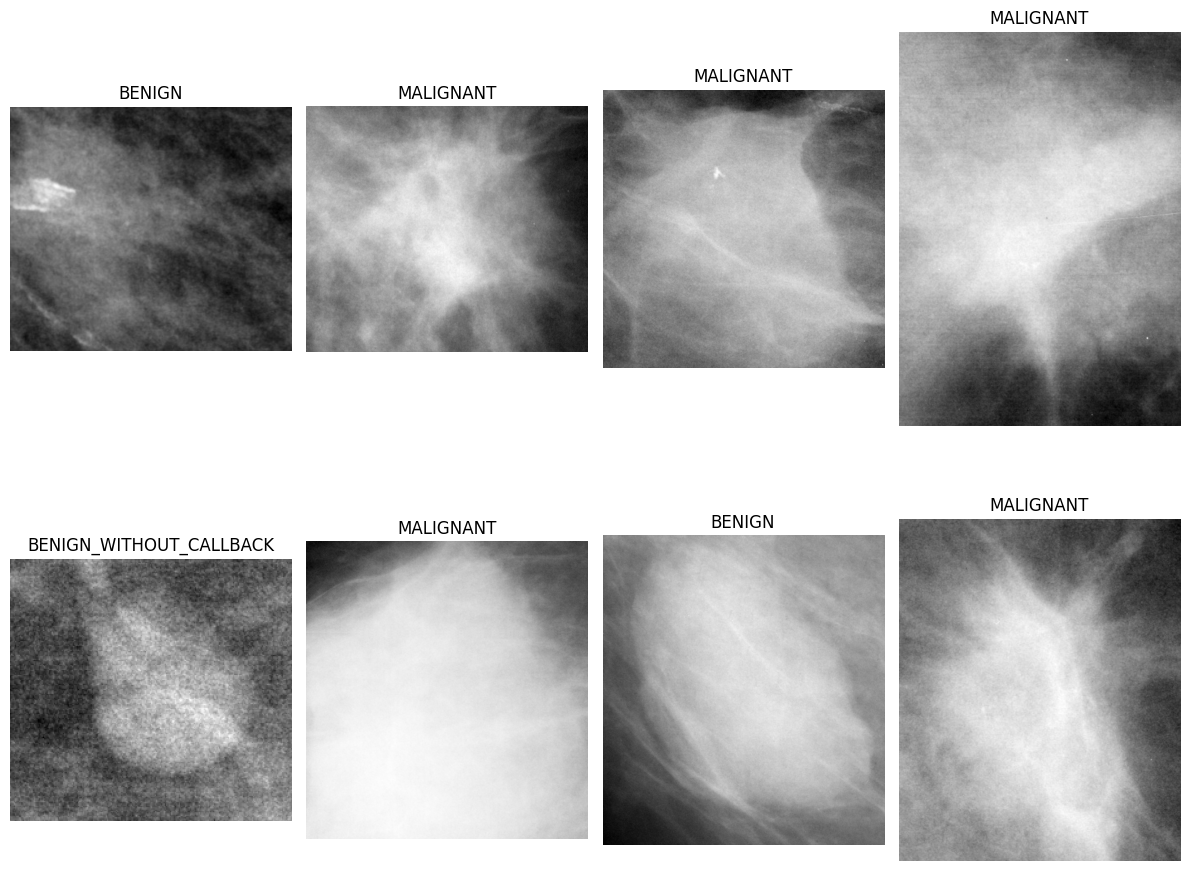

In [19]:
#visually checks the matched images 
samples = train_df.sample(8, random_state=42) #randomly select 8 training cases 

plt.figure(figsize=(12, 10)) #figure for 8 mammograms 

samples = samples.reset_index(drop=True) #resets the row numbers to 0,1,2 etc. 
for i, row in samples.iterrows(): #display each selected mammogram 
    image = Image.open(row["crop_jpeg"]).convert("L")  #open the mammogram as a grayscale image 
    plt.subplot(2, 4, i + 1)
    plt.imshow(image, cmap="gray") #displays the mammogram 
    plt.title(row["pathology"])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Section 3 - Train, Validation, and Test Preparation 

#### This section prepares the datasets used to train and evaluate the CNN models. The CBIS-DDSM data is divided into training and validation sets using a split that ensures no patient leakage, while the test set is kept seperate for the final evaluation.  

In [20]:
#checks whether all the mammograms originally have the same size 
widths = [] 
heights = [] 

for path in train_df["crop_jpeg"]: #checks the size of every training mammogram
    with Image.open(path) as img: #opens the image 
        width, height = img.size 
        widths.append(width)
        heights.append(height)

#displays the range and median image dimensions 
print("Width range:", min(widths), "-", max(widths))
print("Height range:", min(heights), "-", max(heights))
print("Median width:", pd.Series(widths).median())
print("Median height:", pd.Series(heights).median())

Width range: 95 - 1086
Height range: 126 - 1099
Median width: 345.0
Median height: 345.0


In [21]:
#creates the train/validation split 
sgkf = StratifiedGroupKFold( #preserve benign/malignant class balance
    n_splits=5,
    shuffle=True, 
    random_state=42
)

for train_idx, val_idx in sgkf.split(
    train_df, 
    y=train_df["label"], 
    groups=train_df["patient_id"]
):
    break 

#selects the rows assigned to the training/validation sets 
train_split = train_df.iloc[train_idx].reset_index(drop=True)
val_split = train_df.iloc[val_idx].reset_index(drop=True)

test_split = test_df.copy().reset_index(drop=True) #keeps the official test dataset seperate for final evaluation

In [22]:
#count images in each split 
print("Training images:", len(train_split))
print("Validation images:", len(val_split))
print("Test images:", len(test_split))

Training images: 1054
Validation images: 264
Test images: 378


In [23]:
#count patients in each split 
print("Training patients:", train_split["patient_id"].nunique())
print("Validation patients:", val_split["patient_id"].nunique())
print("Test patients:", test_split["patient_id"].nunique())

Training patients: 556
Validation patients: 135
Test patients: 201


In [24]:
#verify there is no patient overlap 
train_patient_ids = set(train_split["patient_id"]) #creates a set containing all patient IDs
val_patient_ids = set(val_split["patient_id"]) #creates a set containing validation patient IDs
test_patient_ids = set(test_split["patient_id"]) #create a set that has all test patient IDs

#counts patients appearing in both training and validation 
print("Train-validation overlap:", len(train_patient_ids & val_patient_ids))

#counts patients appearing in both training and test 
print("Train-test overlap:", len(train_patient_ids & test_patient_ids))

#counts patients appearing in both validation and test 
print("Validation-test overlap:", len(val_patient_ids & test_patient_ids))

Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0


In [25]:
#displays the number of benign and malignant cases in each dataset 
print("Training:")
print(train_split["label"].value_counts(normalize=True).round(3)) #distribution of training set

print("\nValidation:")
print(val_split["label"].value_counts(normalize=True).round(3)) #distribution of validation set

print("\nTest:")
print(test_split["label"].value_counts(normalize=True).round(3)) #distribution of the test set 

Training:
label
0    0.517
1    0.483
Name: proportion, dtype: float64

Validation:
label
0    0.515
1    0.485
Name: proportion, dtype: float64

Test:
label
0    0.611
1    0.389
Name: proportion, dtype: float64


In [26]:
#save the train/validation/test splits 
RESULTS_DIR = ROOT / "results" #create the path to the project's results folder 
RESULTS_DIR.mkdir(exist_ok=True) 

#saves the training split as a CSV file 
train_split.to_csv(RESULTS_DIR / "train_split.csv", index=False)

#saves the validation split as a CSV file 
val_split.to_csv(RESULTS_DIR / "validation_split.csv", index=False)

#saves the test split as a CSV file 
test_split.to_csv(RESULTS_DIR / "test_split.csv", index=False)

In [27]:
#image size and batch size for all mammograms
IMG_HEIGHT = 128 
IMG_WIDTH = 128
BATCH_SIZE = 32

## 4. TensorFlow Input Pipeline

#### This section prepares the cropped mammograms for the CNN models. The image paths and labels from the training, validation, and test dataframes are converted into TensorFlow datasets. Each mammogram is loaded as a grayscale image, resized to 128 x 128 pixels, and normalized to a pixel range of 0-1. 

In [28]:
#extract the image paths and labels 
train_paths = train_split["crop_jpeg"].astype(str).values #converts the training image paths to strings 
train_labels = train_split["label"].values #get the training labels 

val_paths = val_split["crop_jpeg"].astype(str).values #gets the validation image paths then converts them to strings 
val_labels = val_split["label"].values #validation labels 

test_paths = test_split["crop_jpeg"].astype(str).values #converst the test image paths to strings 
test_labels = test_split["label"].values #test labels

In [29]:
#functions that loads and preprocesses one mammogram 
def load_image(path, label):
    image = tf.io.read_file(path) #reads the image file from the path 
    image = tf.image.decode_jpeg(image, channels=1) #decode the JPEG and load it as a single channel grayscal eimage 

    image = tf.image.resize_with_pad( #resize the image preserving its aspect ratio
        image,
        IMG_HEIGHT,
        IMG_WIDTH
    )

    image = tf.cast(image, tf.float32) / 255.0 #convert pixel values to decimal numbers and scale from 0-255 to 0-1
    return image, tf.cast(label, tf.float32) #return the processed image together with the label 

In [30]:
#create TensorFlow datasets 
#creates a dataset from the training image paths and labels
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))

#ds from the validation image paths and labels 
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))

#ds from the test image paths and labels 
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

In [31]:
#load and preprocess every image 
train_ds = train_ds.map(load_image)
val_ds = val_ds.map(load_image)
test_ds = test_ds.map(load_image)

In [32]:
#shuffle the training data 
train_ds = train_ds.shuffle(len(train_split), seed=42)

#groups each dataset into batches of 32 
train_ds = train_ds.batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

#prepares the next batch 
train_ds = train_ds.prefetch(tf.data.AUTOTUNE) #AUTOTUNE means it is allowing TensorFlow to decide how much data it should prepare for the next batch 
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [33]:
#check batch shape, pixel range, and labels 
for images, labels in train_ds.take(1): #takes one batch from the training dataset 
    print("Image batch shape:", images.shape) 
    print("Label batch shape:", labels.shape) 
    print("Pixel range:", images.numpy().min(), "-", images.numpy().max()) #min and max pixel values 
    print("First labels:", labels[:10].numpy()) #displays the labels of the first 10 images in the batch 

Image batch shape: (32, 128, 128, 1)
Label batch shape: (32,)
Pixel range: 0.0 - 1.0
First labels: [1. 0. 0. 1. 0. 0. 1. 0. 1. 1.]


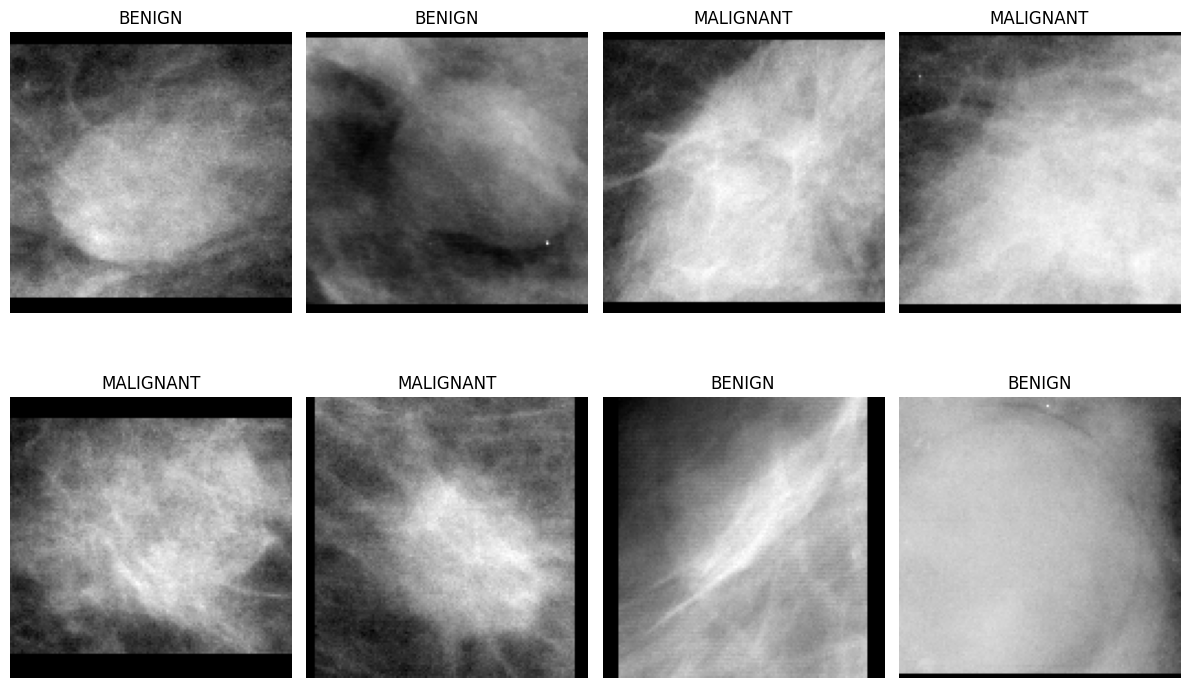

In [34]:
#visually inspect the processed mammograms 
for images, labels in train_ds.take(1): #takes one batch from the training dataset
    plt.figure(figsize=(12, 8))

    for i in range(8): #displays the first 8 images from the batch 
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray") #displays the current processed mammogram in grayscale 

        if labels[i].numpy() == 1: #gets the label name
            label_name = "MALIGNANT"
        else:
            label_name = "BENIGN"

        plt.title(label_name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Pipeline 1: CNN Classification

## 5. Model A: Baseline CNN

#### The baseline CNN was developed using the standard CNN structure demonstrated in TensorFlow's official CNN tutorial. The tutorial uses repeated Conv2D and MaxPooling2D layers to learn image features, followed by Flatten and Dense layers for classification. I used this structure for this classification task. 

#### Source: 
#### TensorFlow (n.d.) ‘Convolutional Neural Network (CNN)’, TensorFlow Core Tutorials. Available at: https://www.tensorflow.org/tutorials/images/cnn 

In [35]:
#sets random seeds so that training can be repeatable
SEED = 42
np.random.seed(SEED) #this makes NumPy's random operations the same 
tf.random.set_seed(SEED) 

In [36]:
#Build Model: baseline convolutional neural network 
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1)), #Input - 128 x 128 grayscale mammogram 

        layers.Conv2D(32, (3, 3), activation="relu"), #first convolutional layer: learns 32 feature maps using a 3 by 3 filter 
        layers.MaxPooling2D((2, 2)), #reduce dimensions to 2 x 2 

        layers.Conv2D(64, (3, 3), activation="relu"), #second convolutional layer: learns 64 feature maps 
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"), #third convolutional layer: learns 128 feature maps 
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(), #converts the 3D feature maps into one long vector 

        layers.Dense(64, activation="relu"), #fully connected layer contains 64 neurons 

        layers.Dense(1, activation="sigmoid") #outputs probability for binary classification 
    ])

    return model

In [37]:
#creates Model A and inspects it 
model_a = build_baseline_model()

model_a.summary() #displays the model's layers, output shapes, and num of parameters 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,698,433 (6.48 MB)

 Trainable params: 1,698,433 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
#compile Model A
model_a.compile(
    optimizer="adam", #updates the model's weights during training 
    loss="binary_crossentropy", #used since there are two classes (0 and 1)
    metrics=[
        "accuracy", #proportion classified correctly 
        keras.metrics.Precision(name="precision"), 
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

In [39]:
#models folder 
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

In [40]:
#train Model A
EPOCHS = 20 

#save the model when validation AUC improves 
checkpoint_a = keras.callbacks.ModelCheckpoint(
    MODELS_DIR / "model_a_baseline_best.keras",
    monitor="val_auc", 
    mode="max", 
    save_best_only=True, 
    verbose=1
)

history_a = model_a.fit(
    train_ds, #training images and labels 
    validation_data=val_ds, #evaluate on validation data after each epoch 
    epochs=EPOCHS, #train for 20 epochs
    callbacks=[checkpoint_a]
)

Epoch 1/20


/opt/homebrew/Cellar/jupyterlab/4.3.4_1/libexec/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.5066 - auc: 0.5000 - loss: 0.6961 - precision: 0.4760 - recall: 0.2141 
Epoch 1: val_auc improved from None to 0.51221, saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/models/model_a_baseline_best.keras

Epoch 1: finished saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/models/model_a_baseline_best.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 334ms/step - accuracy: 0.5066 - auc: 0.5000 - loss: 0.6961 - precision: 0.4760 - recall: 0.2141 - val_accuracy: 0.4924 - val_auc: 0.5122 - val_loss: 0.6925 - val_precision: 0.4867 - val_recall: 0.8594
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.5180 - auc: 0.5151 - loss: 0.6931 - precision: 0.5009 - recall: 0.5776 
Epoch 2: val_auc improved from 0.51221 to 0.52821, saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/models/model_a_baseline_best.keras

Epoch 2: finished saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/models/model_a_ba

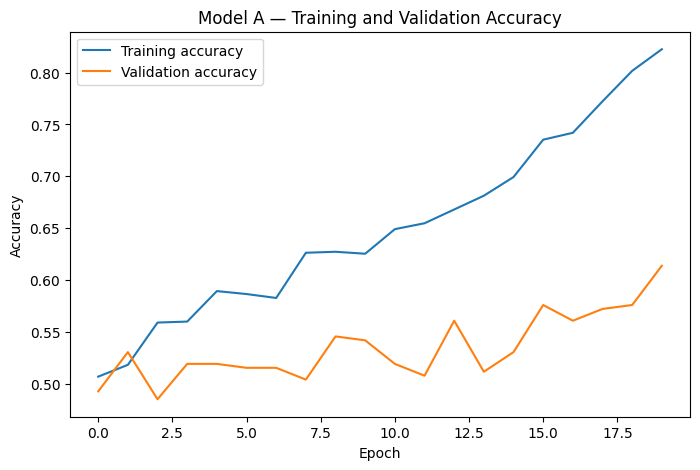

In [41]:
#training vs validation accuracy 
plt.figure(figsize=(8, 5))
plt.plot(history_a.history["accuracy"], label="Training accuracy") #training accuracy across all epochs 
plt.plot(history_a.history["val_accuracy"], label="Validation accuracy") #validation accuracy across all epochs 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model A — Training and Validation Accuracy")
plt.legend()
plt.show()

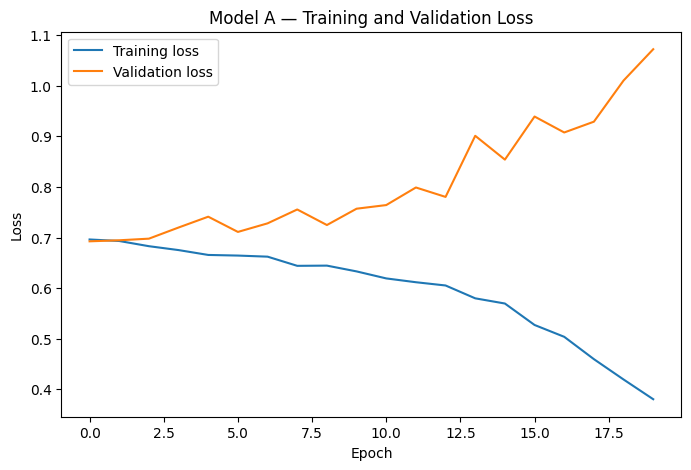

In [42]:
#training vs validation loss 
plt.figure(figsize=(8, 5))

#plots training/validation loss across all epochs 
plt.plot(history_a.history["loss"], label="Training loss")
plt.plot(history_a.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model A — Training and Validation Loss")
plt.legend()
plt.show()

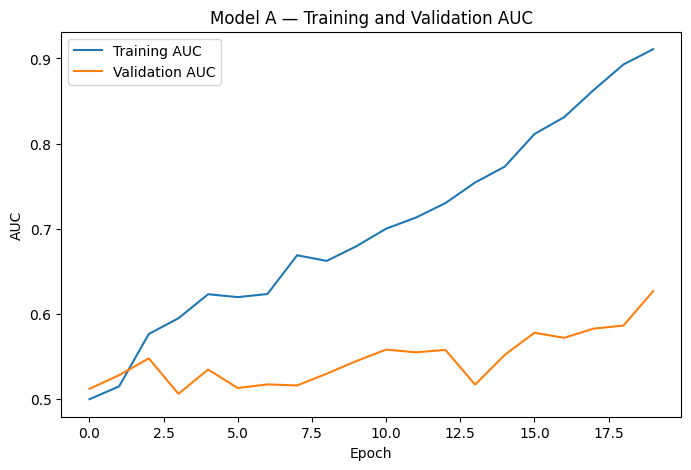

In [43]:
#training vs validation AUC 
plt.figure(figsize=(8, 5))

#plots training/validation AUC across all epochs 
plt.plot(history_a.history["auc"], label="Training AUC")
plt.plot(history_a.history["val_auc"], label="Validation AUC")

plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Model A — Training and Validation AUC")
plt.legend()

plt.show()

In [44]:
#finds which epoch has the highest validation AUC
best_epoch_a = np.argmax(history_a.history["val_auc"]) + 1

#finds the actual validation AUC value 
best_val_auc_a = max(history_a.history["val_auc"])

#finds the highest validation accuracy 
best_val_accuracy_a = max(history_a.history["val_accuracy"])

#displays the best epoch, AUC, and validation 
print("Best validation AUC epoch:", best_epoch_a)
print("Best validation AUC:", round(best_val_auc_a, 4))
print("Best validation accuracy:", round(best_val_accuracy_a, 4))

Best validation AUC epoch: 20
Best validation AUC: 0.6268
Best validation accuracy: 0.6136


In [45]:
#loads the version of Model A that had the best validation AUC
model_a_best = keras.models.load_model(MODELS_DIR / "model_a_baseline_best.keras")

#evaluate the saved model on the validation dataset
best_results_a = model_a_best.evaluate(val_ds,return_dict=True)

best_results_a

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6136 - auc: 0.6268 - loss: 1.0724 - precision: 0.6226 - recall: 0.5156 


{'accuracy': 0.6136363744735718,
 'auc': 0.6267808079719543,
 'loss': 1.0723767280578613,
 'precision': 0.6226415038108826,
 'recall': 0.515625}

In [46]:
#store and save the best Model A metrics 
results_a = pd.DataFrame([best_results_a], index=["Model A - Baseline"]) #converts Model A validation metrics into a one-row df 
results_a.to_csv(RESULTS_DIR / "model_a_best_validation_metrics.csv") #saves the validation metrics to a CSV file

results_a

,accuracy,auc,loss,precision,recall
Model A - Baseline,0.613636,0.626781,1.072377,0.622642,0.515625


## 6. Model B: Scaled CNN

#### Model B tests the effect of increasing CNN capacity. It keeps the same archiecture as the baseline Model A but increases the number of convolutional filters from 32-64-128 to 64-128-256. Increasing the number of filters allows the network to learn a larger number of feature maps. 

In [47]:
def build_scaled_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1)), #128 x 128 grayscale mammogram 

        layers.Conv2D(64, (3, 3), activation="relu"), #first convolutional block - 64 filters 
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"), #second convolutional block: 128 fileters 
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation="relu"), #third convolutional block - 256 filters 
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(), #converts the feature maps into one vector 

        layers.Dense(64, activation="relu"), #fully connected classification layer 

        layers.Dense(1, activation="sigmoid") #outputs probability  
    ])

    return model

In [48]:
model_b = build_scaled_model() #create the model 
model_b.summary() #displays layers and parameter counts 

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,581,057 (13.66 MB)

 Trainable params: 3,581,057 (13.66 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
#same training setting as Model A
model_b.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

In [50]:
#save Model B whenever its validation AUC improves
checkpoint_b = keras.callbacks.ModelCheckpoint(
    MODELS_DIR / "model_b_scaled_best.keras", #file where Model B is stored 
    monitor="val_auc", #decide which model is best using validation AUC
    mode="max",
    save_best_only=True, #only save when validation AUC improves
    verbose=1
)

In [51]:
#train Model B using the same data and number of epochs as Model A
history_b = model_b.fit(
    train_ds, #training dataset
    validation_data=val_ds, #checks validation performance after each epoch 
    epochs=EPOCHS,
    callbacks=[checkpoint_b] #save the model whenever validation AUC improves 
)

Epoch 1/20


/opt/homebrew/Cellar/jupyterlab/4.3.4_1/libexec/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 894ms/step - accuracy: 0.5228 - auc: 0.5163 - loss: 0.6965 - precision: 0.5075 - recall: 0.3969       
Epoch 1: val_auc improved from None to 0.48558, saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/models/model_b_scaled_best.keras

Epoch 1: finished saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/models/model_b_scaled_best.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 34s 973ms/step - accuracy: 0.5228 - auc: 0.5163 - loss: 0.6965 - precision: 0.5075 - recall: 0.3969 - val_accuracy: 0.5152 - val_auc: 0.4856 - val_loss: 0.6951 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 890ms/step - accuracy: 0.5171 - auc: 0.5308 - loss: 0.6919 - precision: 0.0000e+00 - recall: 0.0000e+00 
Epoch 2: val_auc improved from 0.48558 to 0.49997, saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/models/model_b_scaled_best.keras

Epoch 2: finished saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/m

In [52]:
#loads the saved version of Model B with the highest validation AUC 
model_b_best = keras.models.load_model(MODELS_DIR / "model_b_scaled_best.keras")

#evaluate best model on validation dataset
best_results_b = model_b_best.evaluate(val_ds, return_dict=True)

best_results_b

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 235ms/step - accuracy: 0.6023 - auc: 0.5964 - loss: 1.1089 - precision: 0.5793 - recall: 0.6562


{'accuracy': 0.6022727489471436,
 'auc': 0.5963924527168274,
 'loss': 1.1089096069335938,
 'precision': 0.5793103575706482,
 'recall': 0.65625}

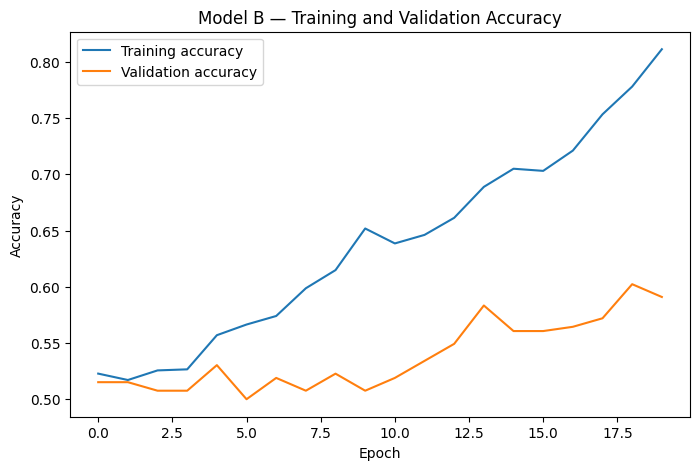

In [53]:
#Model B training vs validation 
plt.figure(figsize=(8, 5))
plt.plot(history_b.history["accuracy"], label="Training accuracy")
plt.plot(history_b.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model B — Training and Validation Accuracy")
plt.legend()
plt.show()

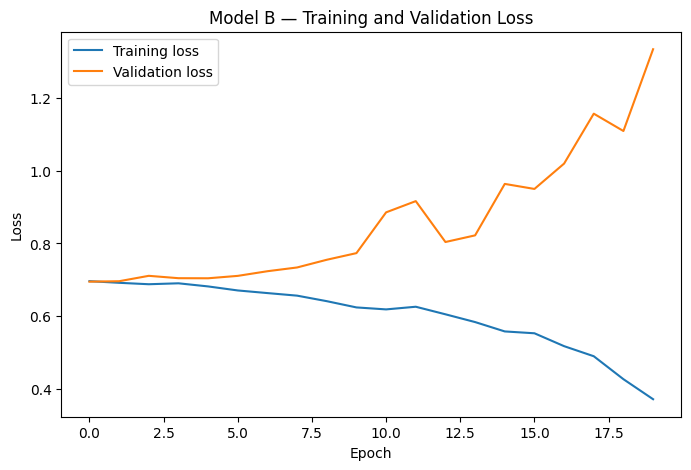

In [54]:
#model B loss curves
plt.figure(figsize=(8, 5))
plt.plot(history_b.history["loss"], label="Training loss")
plt.plot(history_b.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model B — Training and Validation Loss")
plt.legend()
plt.show()

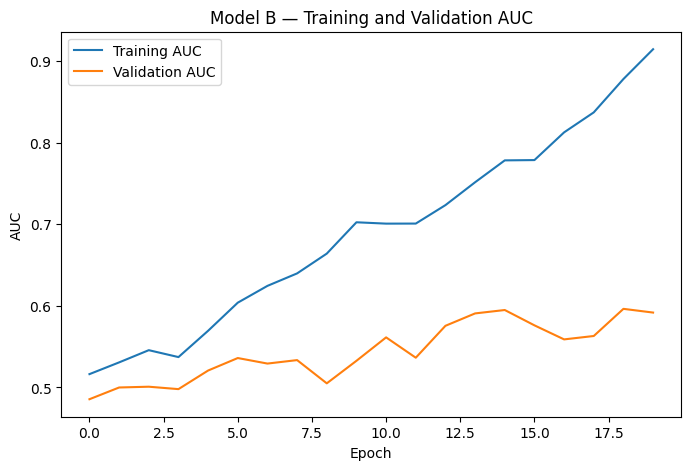

In [55]:
#Model B AUC curves
plt.figure(figsize=(8, 5))
plt.plot(history_b.history["auc"], label="Training AUC")
plt.plot(history_b.history["val_auc"], label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Model B — Training and Validation AUC")
plt.legend()
plt.show()

In [56]:
#converts Model B's best validation metrics into a df 
results_b = pd.DataFrame(
    [best_results_b],
    index=["Model B - Scaled"]
)

#save validation metrics to a CSV file 
results_b.to_csv(RESULTS_DIR / "model_b_best_validation_metrics.csv")

results_b

,accuracy,auc,loss,precision,recall
Model B - Scaled,0.602273,0.596392,1.10891,0.57931,0.65625


## 7. Model C: Regularised CNN

#### This model investigates whether dropout regularization improves the generalization of the scaled CNN. The convolutional architecture remains the same as Model B (64-128-256). During training, dropout randomly removes a proportion of inputs, which can reduce the model's dependence on particular features help reduce overfitting. 

In [57]:
def build_model_c():
    model = keras.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1)), #128 x 128 grayscale mammogram

        layers.Conv2D(64, (3, 3), activation="relu"), #first convolutional block 
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.20), #20% of inputs are dropped randomly 

        layers.Conv2D(128, (3, 3), activation="relu"), #second convolutional block
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.20),

        layers.Conv2D(256, (3, 3), activation="relu"), #third convolutional block 
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        layers.Flatten(),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.50), #drop 50%

        layers.Dense(1, activation="sigmoid")
    ])

    return model

In [58]:
model_c = build_model_c() #creates Model C

#same optimizer, loss, and metrics as the earlier CNNs
model_c.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

model_c.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,581,057 (13.66 MB)

 Trainable params: 3,581,057 (13.66 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
checkpoint_c = keras.callbacks.ModelCheckpoint(#saves the version of Model C with the highest validation AUC
    MODELS_DIR / "model_c_regularised_best.keras",
    monitor="val_auc", 
    mode="max",
    save_best_only=True, #only save when AUC improves 
    verbose=1
)

early_stop_c = keras.callbacks.EarlyStopping( #stop the training if validation AUC stops improving 
    monitor="val_auc", #watch validation AUC
    mode="max", 
    patience=5,#allow 5 epochs without improvement 
    restore_best_weights=True
)

In [60]:
 #train Model C
history_c = model_c.fit(
    train_ds, #training images and labels 
    validation_data=val_ds, #evaluate on validation data each epoch 
    epochs=30,
    callbacks=[checkpoint_c, early_stop_c] #save the best model 
)

Epoch 1/30


/opt/homebrew/Cellar/jupyterlab/4.3.4_1/libexec/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 939ms/step - accuracy: 0.5171 - auc: 0.4907 - loss: 0.7264 - precision: 0.5000 - recall: 0.4381 
Epoch 1: val_auc improved from None to 0.48323, saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/models/model_c_regularised_best.keras

Epoch 1: finished saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/models/model_c_regularised_best.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5171 - auc: 0.4907 - loss: 0.7264 - precision: 0.5000 - recall: 0.4381 - val_accuracy: 0.5152 - val_auc: 0.4832 - val_loss: 0.6931 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5076 - auc: 0.4966 - loss: 0.6935 - precision: 0.4894 - recall: 0.4538    
Epoch 2: val_auc improved from 0.48323 to 0.50000, saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/models/model_c_regularised_best.keras

Epoch 2: finished saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/mod

In [61]:
#load and evaluate the best Model C 
model_c_best = keras.models.load_model(MODELS_DIR / "model_c_regularised_best.keras")

best_results_c = model_c_best.evaluate(val_ds, return_dict=True) #evaluate the saved model on the validation dataset

best_results_c

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 260ms/step - accuracy: 0.4962 - auc: 0.5356 - loss: 0.7051 - precision: 0.4877 - recall: 0.7734


{'accuracy': 0.4962121248245239,
 'auc': 0.5355870723724365,
 'loss': 0.7050963640213013,
 'precision': 0.4876847267150879,
 'recall': 0.7734375}

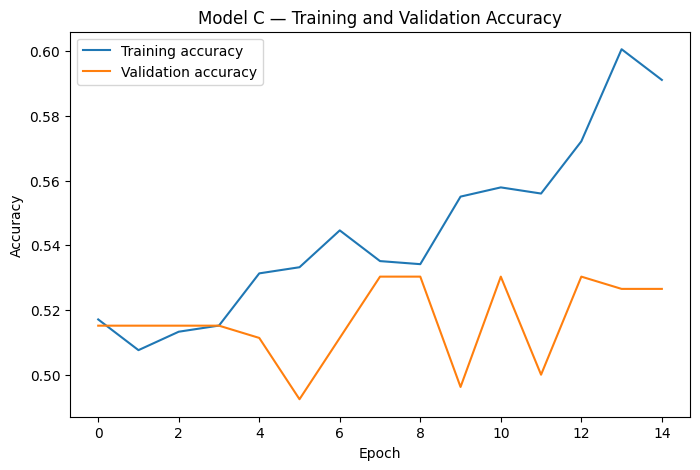

In [62]:
#Model C's accuracy curves
plt.figure(figsize=(8, 5))
plt.plot(history_c.history["accuracy"], label="Training accuracy")
plt.plot(history_c.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model C — Training and Validation Accuracy")
plt.legend()
plt.show()

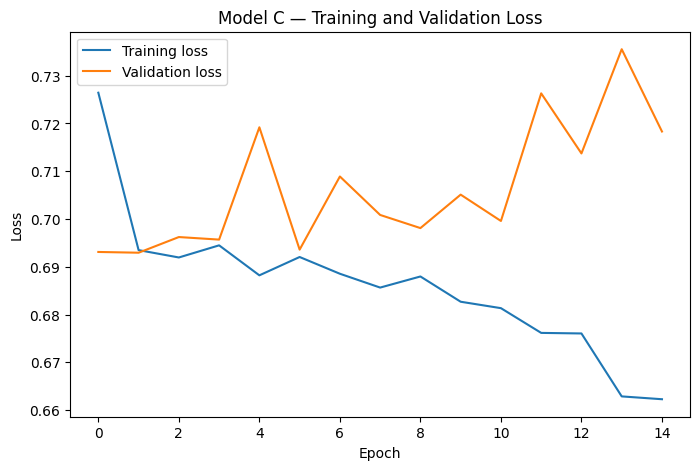

In [63]:
#Model C's loss curves 
plt.figure(figsize=(8, 5))
plt.plot(history_c.history["loss"], label="Training loss")
plt.plot(history_c.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model C — Training and Validation Loss")
plt.legend()
plt.show()

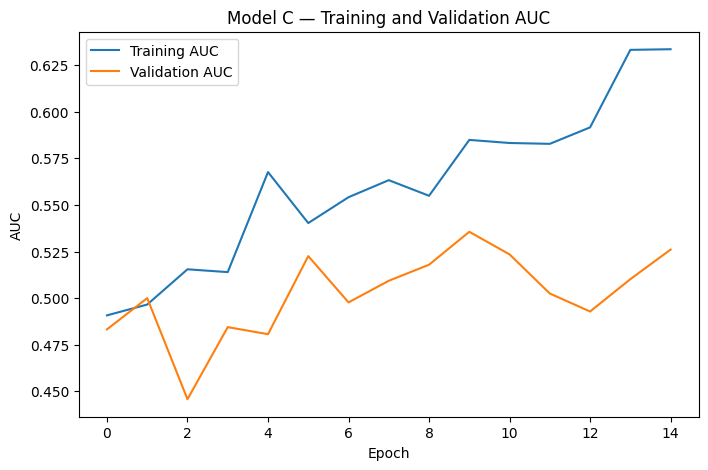

In [64]:
#Model C's AUC curves 
plt.figure(figsize=(8, 5))
plt.plot(history_c.history["auc"], label="Training AUC")
plt.plot(history_c.history["val_auc"], label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Model C — Training and Validation AUC")
plt.legend()
plt.show()

## 8. Model D: Moderately Regularised CNN

#### Tests a less aggressive level of dropout regularization, while keeping the convolutional architture as Models B and C the same. A single dropout layer with a rate of 0.30 is added after the dense layer. 

In [65]:
def build_model_d():
    model = keras.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.30), #30% of input reduced 

        layers.Dense(1, activation="sigmoid")
    ])

    return model

In [66]:
#create, compile, and inspect Model D
model_d = build_model_d()

#same training settings as the previous CNN models 
model_d.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

model_d.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,581,057 (13.66 MB)

 Trainable params: 3,581,057 (13.66 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
#Model D checkpoint and early stopping 
checkpoint_d = keras.callbacks.ModelCheckpoint( #saves the version of Model D with the highest validation AUC
    MODELS_DIR / "model_d_moderate_regularised_best.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stop_d = keras.callbacks.EarlyStopping( #stop training if validation AUC stops improving
    monitor="val_auc",
    mode="max",
    patience=5, #allows 5 epochs without improvement
    restore_best_weights=True
)

In [68]:
history_d = model_d.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint_d, early_stop_d] #save the best model and stop early if needed 
)

Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 901ms/step - accuracy: 0.5066 - auc: 0.5033 - loss: 0.7044 - precision: 0.4675 - recall: 0.1552 
Epoch 1: val_auc improved from None to 0.49018, saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/models/model_d_moderate_regularised_best.keras

Epoch 1: finished saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/models/model_d_moderate_regularised_best.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 34s 983ms/step - accuracy: 0.5066 - auc: 0.5033 - loss: 0.7044 - precision: 0.4675 - recall: 0.1552 - val_accuracy: 0.5114 - val_auc: 0.4902 - val_loss: 0.6954 - val_precision: 0.4912 - val_recall: 0.2188
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 880ms/step - accuracy: 0.5531 - auc: 0.5631 - loss: 0.6890 - precision: 0.5324 - recall: 0.6130 
Epoch 2: val_auc improved from 0.49018 to 0.50195, saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/models/model_d_moderate_regularised_best.keras

Epoch 2: finished saving model to /Users/aliyahfa

In [69]:
#load and evaluate the best Model D 
model_d_best = keras.models.load_model(MODELS_DIR / "model_d_moderate_regularised_best.keras")

#evaluate the best saved model on the validation dataset
best_results_d = model_d_best.evaluate(val_ds, return_dict=True)

best_results_d

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.5265 - auc: 0.5333 - loss: 0.7065 - precision: 0.5138 - recall: 0.4375


{'accuracy': 0.5265151262283325,
 'auc': 0.5332893133163452,
 'loss': 0.7065070271492004,
 'precision': 0.5137614607810974,
 'recall': 0.4375}

## 9. Validation Model Comparison

#### This section compares the best saved validation results from all four CNN models. Each model was selected using its highest validation auc. 

In [70]:
#table comparing the best validation results of all four models 
comparison_validation = pd.DataFrame({
    "Model": [ #names of the four models
        "A - Baseline",
        "B - Scaled",
        "C - Strong Regularisation",
        "D - Moderate Regularisation"
    ],

    "Accuracy": [ #validation accuracy for each model 
        best_results_a["accuracy"],
        best_results_b["accuracy"],
        best_results_c["accuracy"],
        best_results_d["accuracy"]
    ],

    "AUC": [ #validation ROC-AUC for each model 
        best_results_a["auc"],
        best_results_b["auc"],
        best_results_c["auc"],
        best_results_d["auc"]
    ],

    "Precision": [ #validation precision for each model 
        best_results_a["precision"],
        best_results_b["precision"],
        best_results_c["precision"],
        best_results_d["precision"]
    ],

    "Recall": [ #validation recall for each model 
        best_results_a["recall"],
        best_results_b["recall"],
        best_results_c["recall"],
        best_results_d["recall"]
    ],

    "Loss": [ #validation loss for each model (binary cross-entropy)
        best_results_a["loss"],
        best_results_b["loss"],
        best_results_c["loss"],
        best_results_d["loss"]
    ]
})

comparison_validation.round(4)

,Model,Accuracy,AUC,Precision,Recall,Loss
0,A - Baseline,0.6136,0.6268,0.6226,0.5156,1.0724
1,B - Scaled,0.6023,0.5964,0.5793,0.6562,1.1089
2,C - Strong Regularisation,0.4962,0.5356,0.4877,0.7734,0.7051
3,D - Moderate Regularisation,0.5265,0.5333,0.5138,0.4375,0.7065


In [71]:
#saves the validation comparison table
comparison_validation.to_csv(
    RESULTS_DIR / "validation_model_comparison.csv",
    index=False
)

## 10. Final Test Set Evaluation

#### This section evaluates the best saved version of each CNN on the test set. Each model produces a probability of malignancy for eveyr test image. A threshold of 0.5 is then used to convert these probabilties into benign or malignant predictions. The final models are then compared using accuracy, AUC, precision, recall, specificity, F1 score, and confusion-matrix counts. This was implemented using scikit-learn's metrics documentation.

In [72]:
y_true = test_labels.astype(int) #gets the true test labels 

print("Number of test labels:", len(y_true)) #checks how many test examples were collected
print("Benign:", np.sum(y_true == 0)) #counts benign test cases
print("Malignant:", np.sum(y_true == 1)) #counts malignant test cases

Number of test labels: 378
Benign: 231
Malignant: 147


In [73]:
#gets predicted probabilities for every test image 
prob_a = model_a_best.predict(test_ds).ravel() #ravel() turns the result into a one-dimensional array instead of two
prob_b = model_b_best.predict(test_ds).ravel()
prob_c = model_c_best.predict(test_ds).ravel()
prob_d = model_d_best.predict(test_ds).ravel()

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 300ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 285ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 270ms/step


In [74]:
#turn probabilities into predicted classes using a threshold 
pred_a = (prob_a >= 0.5).astype(int) 
pred_b = (prob_b >= 0.5).astype(int)
pred_c = (prob_c >= 0.5).astype(int)
pred_d = (prob_d >= 0.5).astype(int)

In [75]:
#defines the complete evaluation metrics function 
def calculate_metrics(y_true, y_pred, y_prob): #function that calculates all evaluation metrics 
    matrix = confusion_matrix( #confusion matrix 
        y_true, 
        y_pred
    )
    tn = matrix[0,0]
    fp = matrix[0, 1]
    fn = matrix[1,0]
    tp = matrix[1,1]
    
    specificity = tn / (tn + fp) #proportion of benign cases correctly identified 

    return { #all metrics returned in a dictionary 
        "Accuracy": accuracy_score(y_true, y_pred), #proportion of correct classification
        "AUC": roc_auc_score(y_true, y_prob), 
        "Precision": precision_score(y_true, y_pred, zero_division=0), #how many predicted malignant, were actually malignant 
        "Sensitivity (Recall)": recall_score(y_true, y_pred), #how many actual malignant cases were correctly identified 
        "Specificity": specificity, #how many benign cases were correctly identified 
        "F1": f1_score(y_true, y_pred),
        #confusion-matrix counts 
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [76]:
#calculates and combined the final test metrics for all 4 weeks 
final_test_results = pd.DataFrame([
    calculate_metrics(y_true, pred_a, prob_a),
    calculate_metrics(y_true, pred_b, prob_b),
    calculate_metrics(y_true, pred_c, prob_c),
    calculate_metrics(y_true, pred_d, prob_d)
], index=[ #row names 
    "A - Baseline",
    "B - Scaled",
    "C - Strong Regularisation",
    "D - Moderate Regularisation"
])

final_test_results

,Accuracy,AUC,Precision,Sensitivity (Recall),Specificity,F1,TN,FP,FN,TP
A - Baseline,0.611111,0.606708,0.500000,0.537415,0.658009,0.518033,152,79,68,79
B - Scaled,0.568783,0.580676,0.463636,0.693878,0.489177,0.555858,113,118,45,102
C - Strong Regularisation,0.441799,0.553553,0.394040,0.809524,0.207792,0.530067,48,183,28,119
D - Moderate Regularisation,0.560847,0.552876,0.435374,0.435374,0.640693,0.435374,148,83,83,64


In [77]:
final_test_results.to_csv(RESULTS_DIR / "final_test_results.csv")

## 11. Confusion Matrices and ROC Analysis

#### This section visually shows the performance of Models A - D. Confusion matrices and ROC curves are displayed. Both were implemented using the official scikit-learn documentation. 

In [78]:
FIGURES_DIR = ROOT / "figures" #path to figures folder 
FIGURES_DIR.mkdir(exist_ok=True)

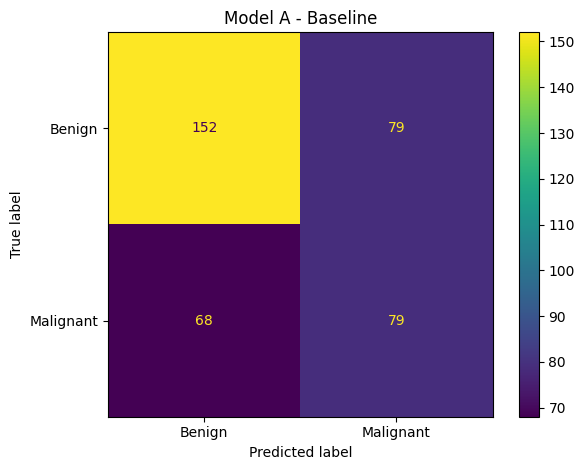

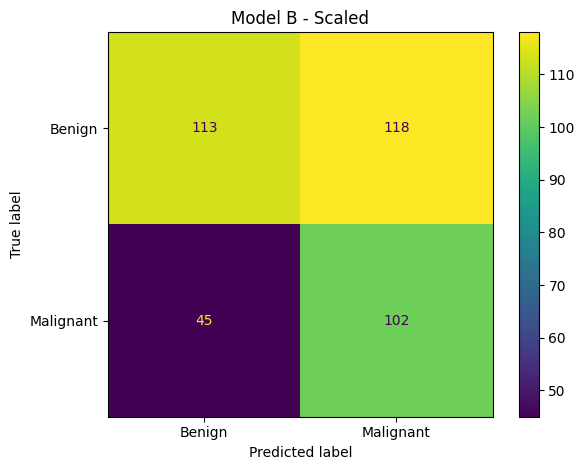

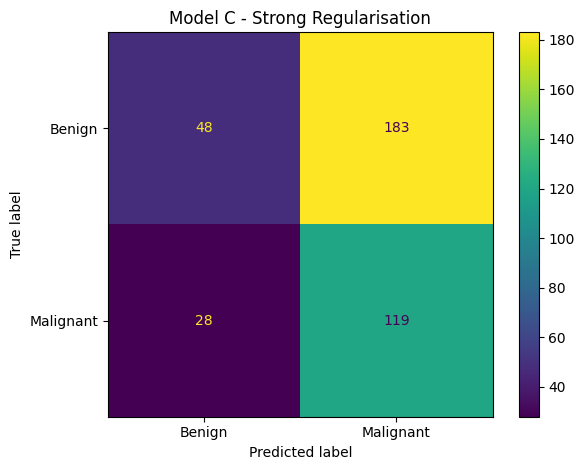

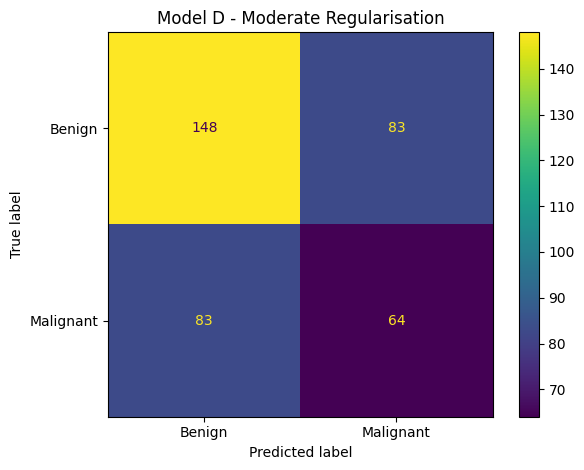

In [79]:
models_predictions = [ #store each model name together with its predicted test labels 
    ("Model A - Baseline", pred_a, "model_a_confusion_matrix.png"),
    ("Model B - Scaled", pred_b, "model_b_confusion_matrix.png"),
    ("Model C - Strong Regularisation", pred_c, "model_c_confusion_matrix.png"),
    ("Model D - Moderate Regularisation", pred_d, "model_a_confusion_matrix.png")
]

for name, predictions, filename in models_predictions: #loop through each model and its predictions 
    ConfusionMatrixDisplay.from_predictions( #creates and displays the confusion matrix 
        y_true,
        predictions,
        display_labels=["Benign", "Malignant"]
    )

    plt.title(name)
    plt.tight_layout()

    plt.savefig( #saves confusion matrix as an image file 
        FIGURES_DIR / filename,
        bbox_inches="tight"
    )

    plt.show()

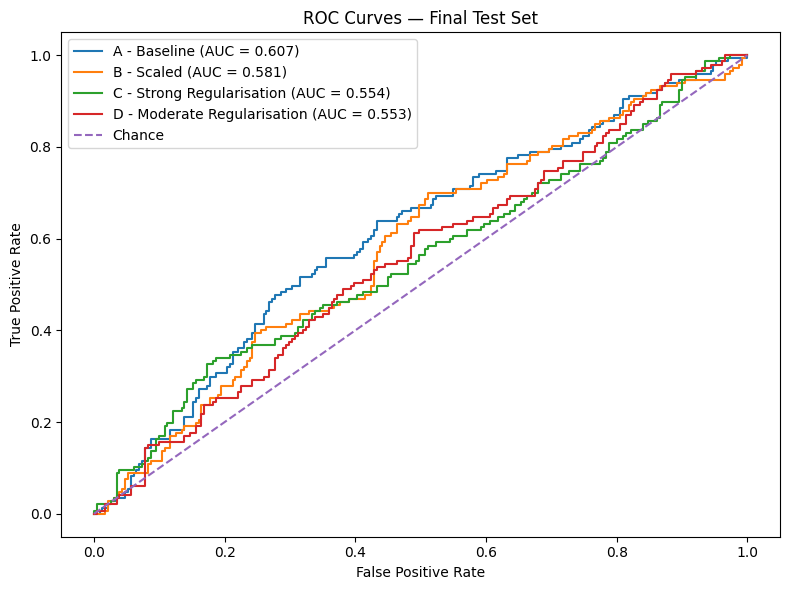

In [80]:
models_probabilities = [ #store each model's name together with predicted malignant probabilities 
    ("A - Baseline", prob_a),
    ("B - Scaled", prob_b),
    ("C - Strong Regularisation", prob_c),
    ("D - Moderate Regularisation", prob_d)
]

plt.figure(figsize=(8, 6))


for name, probabilities in models_probabilities: #calculate and plot the ROC curve for each model 
    fpr, tpr, thresholds = roc_curve(y_true, probabilities) #false-positive rate and true-positive rate 
    auc_score = roc_auc_score(y_true, probabilities) #calculate the model's ROC-AUC

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Chance") #plots the diagonal reference line representing the change level ranking 

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Final Test Set")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "final_test_roc_curves.png",
    bbox_inches="tight"
)

plt.show()

## 12. Model B Prediction Examples

#### This section looks at each prediction made by Model B on the final test set. Each test case is then classified as true positive, true negative, false positive, or false negative. 

In [81]:
#builds a Model B error-analysis table
error_analysis_b = test_split.copy() #copies the test-set metadata for Model B error analysis 

error_analysis_b["probability_malignant"] = prob_b #adds Model B's predicted probability of malignancy for each test image 
error_analysis_b["predicted_label"] = pred_b #add Model B's final 0/1 prediction using the 0.5 threshold 
error_analysis_b["true_label"] = y_true #add the true 0/1 test label 

In [82]:
#assigns every Model B prediction a type 
def get_prediction_type(row):#prediction outcome for one row 
    if row["true_label"] == 1 and row["predicted_label"] == 1:
        return "True Positive" #actually malignant and predicted malignant 
    elif row["true_label"] == 0 and row["predicted_label"] == 0:
        return "True Negative" #actually benign and predicted benign 
    elif row["true_label"] == 0 and row["predicted_label"] == 1:
        return "False Positive" #actually benign but predicted malignant 
    else:
        return "False Negative" #actually malignant but predicted benign

error_analysis_b["prediction_type"] = error_analysis_b.apply( #applies to every row of the DataFrame
    get_prediction_type,
    axis=1
)

print(error_analysis_b["prediction_type"].value_counts())
error_analysis_b.to_csv(RESULTS_DIR / "model_b_test_predictions.csv", index=False)

prediction_type
False Positive    118
True Negative     113
True Positive     102
False Negative     45
Name: count, dtype: int64


In [83]:
#two examples from each prediction 
#selects two true-positive examples 
true_positive_examples = error_analysis_b[
    error_analysis_b["prediction_type"] == "True Positive"].sample(2, random_state=42)
#selects two true-negative examples
true_negative_examples = error_analysis_b[
    error_analysis_b["prediction_type"] == "True Negative"].sample(2, random_state=42)
#selects two false-positive examples 
false_positive_examples = error_analysis_b[
    error_analysis_b["prediction_type"] == "False Positive"].sample(2, random_state=42)
#selects two false-negative examples 
false_negative_examples = error_analysis_b[
    error_analysis_b["prediction_type"] == "False Negative"].sample(2, random_state=42)

#combine eight examples into one dataframe 
example_predictions = pd.concat(
    [
        true_positive_examples, 
        true_negative_examples, 
        false_positive_examples, 
        false_negative_examples 
    ]
).reset_index(drop=True)

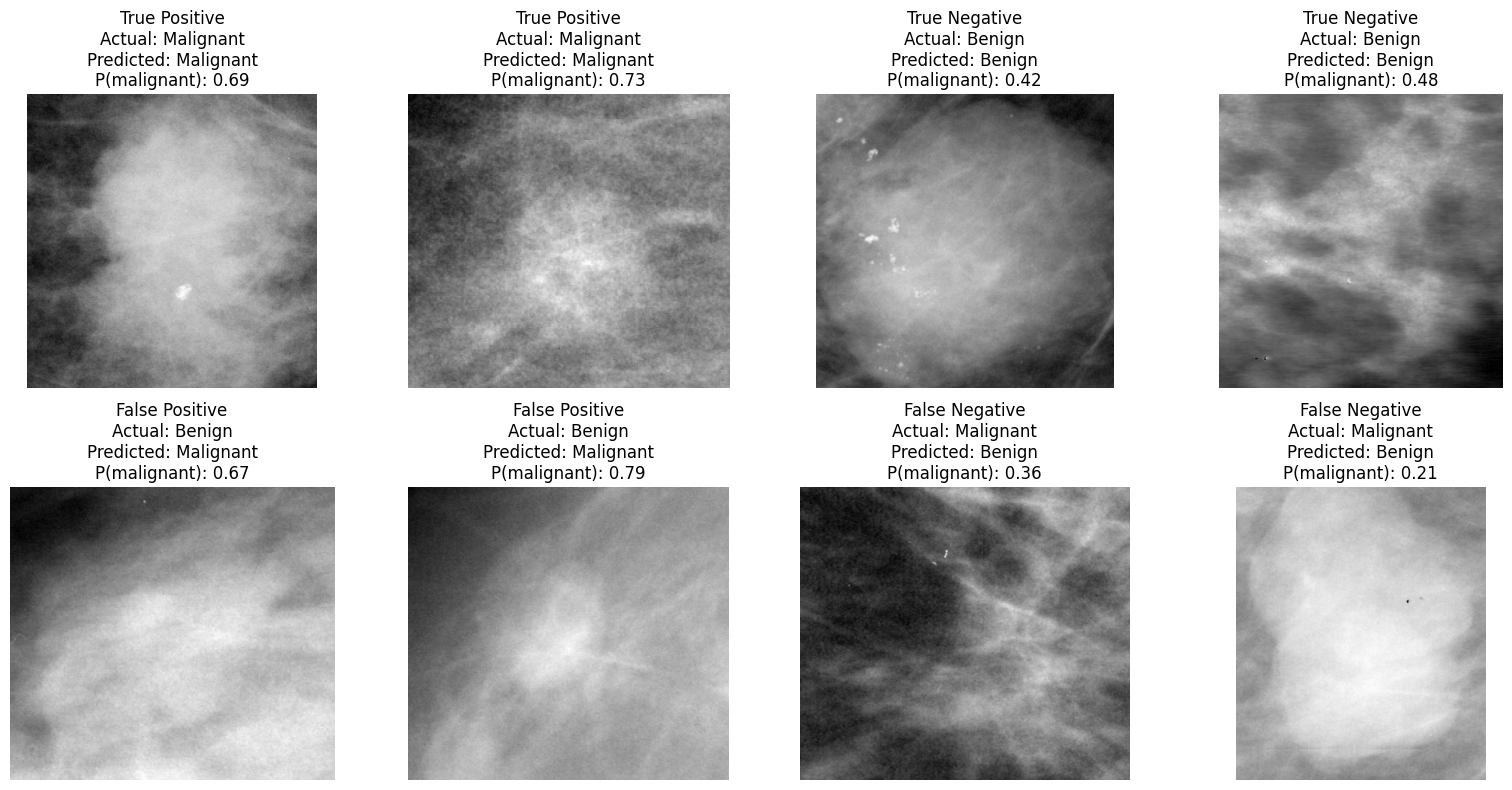

In [84]:
#plots the eight Model B examples 
plt.figure(figsize=(16, 8))

for i in range(len(example_predictions)): #loops through eight selected prediction examples 
    row = example_predictions.iloc[i]
    img = Image.open(row["crop_jpeg"]).convert("L") #opens the cropped mammogram image and converts to grayscale
    #converts the actual label into a proper class name  
    if row["true_label"] == 1:
        true_name = "Malignant"
    else:
        true_name = "Benign"

    if row["predicted_label"] == 1:
        predicted_name = "Malignant"
    else:
        predicted_name = "Benign"
        
    plt.subplot(2, 4, i + 1)

    plt.imshow(img, cmap="gray")
    plt.title(
        f"{row['prediction_type']}\n"
        f"Actual: {true_name}\n"
        f"Predicted: {predicted_name}\n"
        f"P(malignant): {row['probability_malignant']:.2f}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "model_b_prediction_examples.png",
    bbox_inches="tight"
)

plt.show()

In [85]:
#saves the eight frames used in the figure
example_predictions.to_csv(
    RESULTS_DIR / "model_b_prediction_examples.csv",
    index=False
)

# Pipeline 2: Malignant Lesion Localization

#### Malignant Lesion Localization Overview 
#### 1. Match each mass lesion record to its mammogram and ROI mask.
#### 2. Group mass lesions belonging to the same mammogram and combine malignant ROI masks 
#### 3. Resize each mammogram and mask to 256 x 256 pixels 
#### 4. Load the image-mask pair into TensorFlow datasets 
#### 5. Train a U-Net to predict probability for every pixel to be a malignant lesion 
#### 6. Select the probability threshold using the validation set 
#### 7. Evaluate localization performance on test set

#### TensorFlow's image segmentation tutorial and the Keras U-Net segmentation example were used to understand the practical implementation of image-mask input pairs and encoder/decoder models. 

#### Sources:
#### - TensorFlow Image Segmentation: TensorFlow (n.d.) ‘Image segmentation’, TensorFlow Core Tutorials. Available at: https://www.tensorflow.org/tutorials/images/segmentation 
#### - Keras U-Net Image Segmentation: Chollet, F. (2019) ‘Image segmentation with a U-Net-like architecture’, Keras Code Examples. Last modified 20 April 2020. Available at: https://keras.io/examples/vision/oxford_pets_image_segmentation/ 

## 13. ROI Mask and Full Mammogram Preparation

#### The second pipeline uses full mammograms and their corresponding ROI masks to locate the malignant mass lesion. This section maps each CBIS-DDSM mass record to the ROI mask JPEG and full mammogram JPEG. 

In [86]:
#extract the ROI mask UID for each case 
train_df["roi_series_uid"] = train_df[
    "ROI mask file path"
].apply(extract_series_uid)

test_df["roi_series_uid"] = test_df[
    "ROI mask file path"
].apply(extract_series_uid)

In [87]:
#find every JPEG in the dataset
all_jpegs = list(JPEG_DIR.rglob("*.jpg"))

print("Total JPEG files:", len(all_jpegs))

Total JPEG files: 10237


In [88]:
#groups JPEGs by UID folder 

jpeg_candidates_by_uid = {}

for path in all_jpegs: #examine every JPEG file that was found 
    uid = path.parent.name #parent folder's name is the series UID
    if uid not in jpeg_candidates_by_uid: #if this UID has not been seen before, create an empty list for it 
        jpeg_candidates_by_uid[uid] = []
    jpeg_candidates_by_uid[uid].append(path) #add this JPEG path to that UID's list

print( #display how many unique UID folders were found 
    "Unique series UID folders:",
    len(jpeg_candidates_by_uid)
)

Unique series UID folders: 6774


In [89]:
#identify which UIDs really belong to ROI masks 
roi_metadata = dicom_df[
    dicom_df["SeriesDescription"]
    .astype(str)
    .str.strip()
    .eq("ROI mask images")
].copy()

#store the ROI mask series UIDs
roi_uids = set(
    roi_metadata["SeriesInstanceUID"].astype(str)
)

print(
    "ROI mask series in dicom_info:",
    len(roi_uids)
)

ROI mask series in dicom_info: 3247


In [90]:
#find the ROI-mask JPEG that belongs to the series UID
def find_roi_jpeg(uid):
    uid = str(uid) #UID as text 
    
    #rejects the UID if they are not ROI masks  
    if uid not in roi_uids:
        return None
    
    #get all JPEGs stored under the UID folder 
    candidates = jpeg_candidates_by_uid.get(uid, [])

    #no matching JPEG was found 
    if len(candidates) == 0:
        return None

    #if only one JPEG exists, use it 
    if len(candidates) == 1:
        return str(candidates[0])

    #if there are several JPEGs, keep track of which one has the largest dark-background proportion
    best_path = None
    best_zero_fraction = -1

    for path in candidates: #examine every candidate JPEG

        image = np.array( #open the image as grayscale and conver it to NumPy array 
            Image.open(path).convert("L")
        )

        zero_fraction = np.mean( #calculate the fraction of pixels that are almost black 
            image <= 5
        )

        if zero_fraction > best_zero_fraction: #keep this image if it has more dark background 
            best_zero_fraction = zero_fraction
            best_path = path

    return str(best_path)

In [91]:
#map every case to its ROI JPEG 
train_df["roi_jpeg"] = train_df[
    "roi_series_uid"
].apply(find_roi_jpeg)

test_df["roi_jpeg"] = test_df[
    "roi_series_uid"
].apply(find_roi_jpeg)

In [92]:
#verifies that every ROI mask was found 
print(
    "Train ROI masks found:",
    train_df["roi_jpeg"].notna().sum(),
    "/",
    len(train_df)
)

print(
    "Test ROI masks found:",
    test_df["roi_jpeg"].notna().sum(),
    "/",
    len(test_df)
)

Train ROI masks found: 1318 / 1318
Test ROI masks found: 378 / 378


In [93]:
#isolates full mammograms in dicom_info 
full_info = dicom_df[ #keeps only metadata rows that describe full mammogram images 
    dicom_df["SeriesDescription"]
    .astype(str) #ensures the descriptions are strings 
    .str.strip() #remove whitespace 
    == ("full mammogram images") #keep only full mammograms 
].copy()

print(
    "Full mammogram images in metadata:",
    len(full_info)
)

Full mammogram images in metadata: 2857


In [94]:
#converts full-mammogram metadata paths into local JPEG paths 

full_info["local_path"] = full_info[ #convert each CBIS-DDSM image path to local JPEG path
    "image_path"
].apply(make_local_path)

print( #checks how many local JPEG files exist
    "Full mammogram JPEGs found:",
    full_info["local_path"]
    .apply(lambda p: p.exists())
    .sum(),
    "/",
    len(full_info)
)

Full mammogram JPEGs found: 2857 / 2857


In [95]:
#extracts the full-mammogram series UID for each mass record 
train_df["full_series_uid"] = train_df[
    "image file path"
].apply(extract_series_uid)

test_df["full_series_uid"] = test_df[
    "image file path"
].apply(extract_series_uid)

In [96]:
#builds the full-mammogram lookup dictionary 
unique_full_images = full_info.drop_duplicates( #keeps only one metadata row for each unique series UID 
        subset="SeriesInstanceUID"
    )

#creates a lookup from Series UID to the local JPEG path 
full_lookup = unique_full_images.set_index(
    "SeriesInstanceUID"
)["local_path"].to_dict()

In [97]:
#maps every mass record to its full mammogram
train_df["full_jpeg"] = train_df[ 
    "full_series_uid"
].map(full_lookup)

test_df["full_jpeg"] = test_df[
    "full_series_uid"
].map(full_lookup)

In [98]:
#verify that every case has a full mammogram
print(
    "Train full mammograms found:",
    train_df["full_jpeg"].notna().sum(),
    "/",
    len(train_df)
)

print(
    "Test full mammograms found:",
    test_df["full_jpeg"].notna().sum(),
    "/",
    len(test_df)
)

Train full mammograms found: 1318 / 1318
Test full mammograms found: 378 / 378


In [99]:
def show_full_image_and_mask(row): #checks and visualizes a full mammogram together with its ROI mask
    full_image = np.array( 
        Image.open(
            row["full_jpeg"]
        ).convert("L")
    )
    roi_mask = np.array(
        Image.open(
            row["roi_jpeg"]
        ).convert("L")
    )
    print( #displays the patient identifer 
        "Patient:",
        row["patient_id"]
    )

    print(
        "Pathology:",
        row["pathology"]
    )

    print( #displays the dimensions of the full mammogram
        "Full image shape:",
        full_image.shape
    )

    print( #displays the dimensions of the ROI mask 
        "ROI mask shape:",
        roi_mask.shape
    )

    print( #checks if two images use the same pixel dimensions 
        "Shapes match:",
        full_image.shape == roi_mask.shape
    )

    #hides the black background of the mask for the overlay 
    visible_mask = np.ma.masked_where(
        roi_mask <= 5, 
        roi_mask 
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 7)
    )

    #original full mammogram
    axes[0].imshow(
        full_image,
        cmap="gray"
    )

    axes[0].set_title(
        "Full Mammogram"
    )

    axes[0].axis("off")


    #ROI mask 
    axes[1].imshow(
        roi_mask,
        cmap="gray"
    )

    axes[1].set_title(
        "Ground-Truth ROI Mask"
    )

    axes[1].axis("off")


    #Overlay
    axes[2].imshow(
        full_image,
        cmap="gray"
    )

    axes[2].imshow( #overlays only the non-background region of the ROI mask 
        visible_mask, 
        alpha=0.6
    )

    axes[2].set_title(
        "Ground-Truth Lesion Location"
    )

    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

Patient: P_00001
Pathology: MALIGNANT
Full image shape: (4808, 3024)
ROI mask shape: (4808, 3024)
Shapes match: True


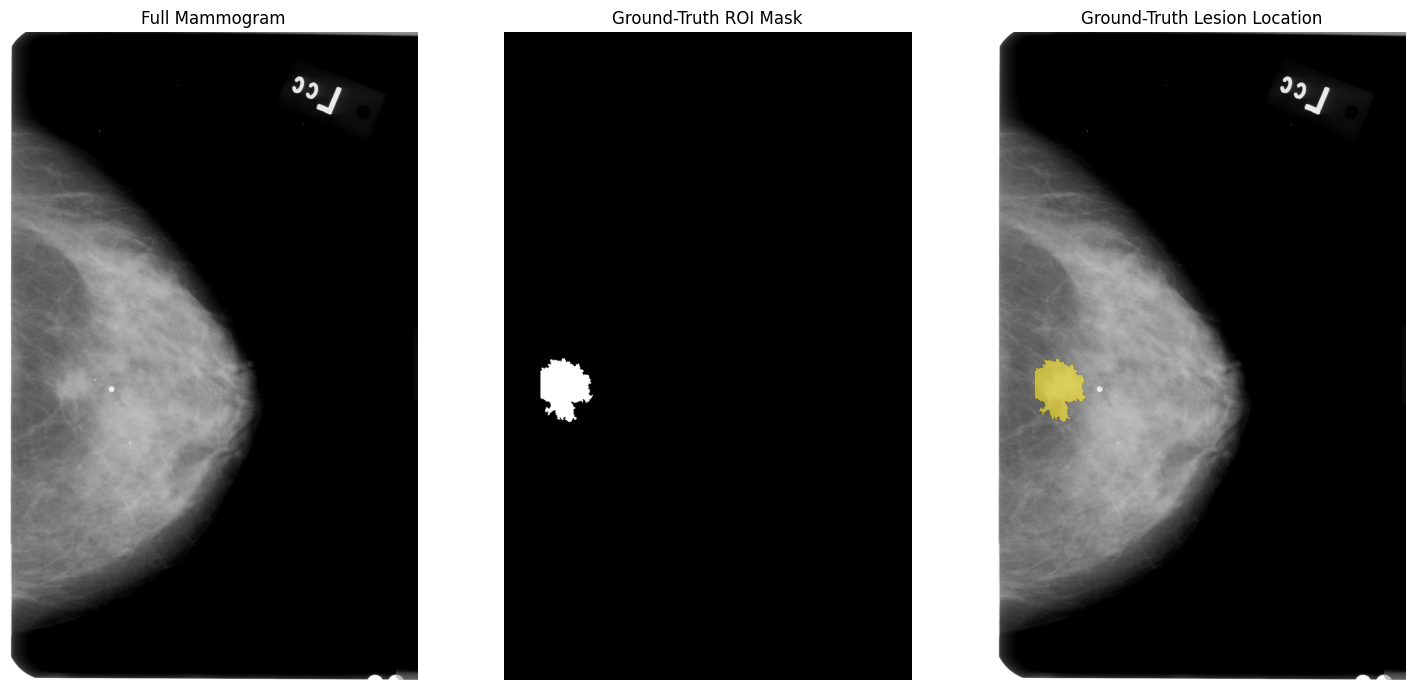

In [100]:
#tests one full mammogram + mask
example = train_df[
    train_df["full_jpeg"].notna()
    & train_df["roi_jpeg"].notna()
].iloc[0]

show_full_image_and_mask(example)

## 14. Malignant Mass Localization Dataset Preparation

#### This section converts the CBIS-DDSM mass lesion data into a full mammogram segmentation dataset. Data that belongs to the same mammogram are grouped together, while their ROI masks are included in the segmentation mask. Mammograms without a malignant mass therefore have an empty mask. 

In [101]:
#build the segmentation dataset 

all_mass_rows = pd.concat( #combines the original development and official test metadata
    [
        train_df, #development mass rows 
        test_df #test mass rows 
    ],
    ignore_index=True
)

segmentation_cases = [] #segmentation record for each full mammogram 

for full_uid, group in all_mass_rows.groupby( #groups all mass records that belong to the same mammogram
    "full_series_uid",
    sort=True
):
    #gets the patient and full mammogram path 
    patient_id = group[ "patient_id"].iloc[0]
    full_jpeg = group["full_jpeg"].iloc[0]
    #selects only ROI masks belonging to malignant masses 
    malignant_rows = group[group["label"] == 1]

    malignant_masks = ( 
        malignant_rows["roi_jpeg"]
        .dropna() #remove missing mask paths
        .astype(str) #converts paths to strings 
        .unique() #removes duplicate mask paths 
        .tolist() #converts the result into a normal Python list 
    )

    has_malignant = int( #record whether this full mammogram contains at least one malignant mass
        len(malignant_masks) > 0
    )
    #preserve the data
    if patient_id in train_patient_ids:
        split = "train"

    elif patient_id in val_patient_ids:
        split = "validation"

    elif patient_id in test_patient_ids:
        split = "test"

    else:
        continue

    segmentation_cases.append( #add one segmentation record for this full mammogram
        {
            "patient_id": patient_id,
            "full_series_uid": full_uid,
            "full_jpeg": str(full_jpeg),
            "malignant_roi_paths": malignant_masks,
            "has_malignant": has_malignant,
            "split": split
        }
    )


seg_df = pd.DataFrame( #converts all segmentation records into a DataFrame
    segmentation_cases
)

print( #Displays the number of unique full mammograms 
    "Unique full mammograms:",
    len(seg_df)
)

print( #counts malignant and non-malignant mammograms in each split 
    seg_df.groupby(
        ["split", "has_malignant"]
    ).size()
)

Unique full mammograms: 1592
split       has_malignant
test        0                216
            1                145
train       0                503
            1                479
validation  0                126
            1                123
dtype: int64


In [102]:
#verifies that patient leakage did not occur 
#gets all patients belonging to the segmentation training/validation/test splits 
seg_train_patients = set(
    seg_df.loc[
        seg_df["split"] == "train",
        "patient_id"
    ]
)

seg_val_patients = set(
    seg_df.loc[
        seg_df["split"] == "validation",
        "patient_id"
    ]
)

seg_test_patients = set(
    seg_df.loc[
        seg_df["split"] == "test",
        "patient_id"
    ]
)

print( #checks whether any patient appears in both train and validation 
    "Train / validation overlap:",
    len(
        seg_train_patients
        & seg_val_patients
    )
)

print( #checks if any patient appears in both train and test
    "Train / test overlap:",
    len(
        seg_train_patients
        & seg_test_patients
    )
)

print( #checks if any patient appears in both validation and test 
    "Validation / test overlap:",
    len(
        seg_val_patients
        & seg_test_patients
    )
)

Train / validation overlap: 0
Train / test overlap: 0
Validation / test overlap: 0


In [103]:
#creates the 256 x 256 localization folders 
LOCALIZATION_SIZE = 256 #image size 

#main directory for the resized localization dataset 
LOCALIZATION_DIR = (DATA_DIR/ "localization_256")

#create a path for resized full mammogram images 
LOCALIZATION_IMAGE_DIR = (LOCALIZATION_DIR/ "images")

#creates a path for resized segmentation masks 
LOCALIZATION_MASK_DIR = (LOCALIZATION_DIR/ "masks")

LOCALIZATION_IMAGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOCALIZATION_MASK_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [104]:
#a function that prepares one mammogram-mask pair 
def prepare_localization_case(row, case_number):
    full_image = np.array( #opens the original mammogram and converts it to a NumPy array 
        Image.open(
            row["full_jpeg"]
        ).convert("L")
    )

    full_h, full_w = full_image.shape #original mammogram height and width 

    combined_mask = np.zeros( #creates an empty binary mask with exactly the same dimensions as the full mammogram 
        full_image.shape,
        dtype=np.uint8
    )

    #loop through malignant ROI masks 
    for mask_path in row["malignant_roi_paths"]:

        roi = np.array(
            Image.open(
                mask_path
            ).convert("L")
        )

        roi_h, roi_w = roi.shape #record the ROI mask's height and width 

        #checks whether image and ROI dimensions match 
        if roi.shape != full_image.shape:

            full_aspect = full_w / full_h #calculates the width-to-height ratio of the mammogram
            roi_aspect = roi_w / roi_h #calculates the width-to-height ratio of the ROI mask 

            aspect_difference = abs( #calculates the relative difference between those aspect ratios 
                full_aspect - roi_aspect
            ) / full_aspect

            #only resize the ROI if its aspect ratio differs from the mammogram by less than 1%
            if aspect_difference < 0.01:

                roi = np.array( #converts the NumPy mask back into a PIL image, resize it to exactly match the mammogram dimensions, and convert it back into a NumPy array 
                    Image.fromarray(roi).resize(
                        (full_w, full_h),
                        resample=Image.Resampling.NEAREST #use nearest-neighbour interpolation 
                    )
                )

            #if the proportions don't agree 
            else:
                raise ValueError(
                    f"Suspicious image/mask mismatch\n"
                    f"Patient: {row['patient_id']}\n"
                    f"Image: {full_image.shape}\n"
                    f"Mask: {roi.shape}\n"
                    f"Aspect difference: "
                    f"{aspect_difference:.4f}"
                )

        #converts the ROI to binary 
        binary_roi = (
            roi > 5
        ).astype(np.uint8)

        combined_mask = np.maximum( #combined multiple malignant lesions 
            combined_mask,
            binary_roi
        )

    #converts image and mask into TensorFlow tensors 
    image_tensor = tf.convert_to_tensor(
        full_image[:, :, np.newaxis],
        dtype=tf.float32
    )

    mask_tensor = tf.convert_to_tensor(
        combined_mask[:, :, np.newaxis],
        dtype=tf.float32
    )

    #resize the mammogram and mask 
    image_resized = tf.image.resize_with_pad(
        image_tensor,
        LOCALIZATION_SIZE,
        LOCALIZATION_SIZE,
        method="bilinear" #biliean interpolation for the mammogram image 
    )

    mask_resized = tf.image.resize_with_pad( #resize the segmentation mask using exactly the same
        mask_tensor,
        LOCALIZATION_SIZE,
        LOCALIZATION_SIZE,
        method="nearest"
    )

    #converts the resized mammogram from a TensorFlow tensor back into a NumPy array
    image_resized = np.clip(
        image_resized.numpy().squeeze(), 
        0,
        255
    ).astype(np.uint8)

    mask_resized = ( #re-binarize the resized mask 
        mask_resized.numpy().squeeze()
        > 0.5
    ).astype(np.uint8) * 255 #stores the final image using 8-bit pixel values 

    #output file names 
    image_output = (
        LOCALIZATION_IMAGE_DIR
        / f"case_{case_number:04d}.png"
    )

    mask_output = (
        LOCALIZATION_MASK_DIR
        / f"case_{case_number:04d}.png"
    )
    #save the prepared pair 
    Image.fromarray(
        image_resized
    ).save(image_output)

    Image.fromarray(
        mask_resized
    ).save(mask_output)

    positive_pixels = int( #counts the lesion pixels 
        np.sum(mask_resized > 0)
    )

    return (
        str(image_output),
        str(mask_output),
        positive_pixels
    )

In [105]:
#prepares the cases 
prepared_images = []
prepared_masks = []
mask_pixels = []

for i in range(len(seg_df)): #process every segmentation case 
    row = seg_df.iloc[i]
    image_path, mask_path, pixels = ( #prepare the mammogram and mask 
        prepare_localization_case(
            row,
            i
        )
    )

    prepared_images.append( #store the prepared mammogram path 
        image_path
    )

    prepared_masks.append( #store the prepares mask path 
        mask_path
    )

    mask_pixels.append( #store the number of positive pixels in the resized mask 
        pixels
    )

    if ( #print progress every 100 cases 
        (i + 1) % 100 == 0
        or i == len(seg_df) - 1
    ):
        print( #displays the current progress 
            f"Prepared "
            f"{i + 1} / "
            f"{len(seg_df)}"
        )

seg_df[ #adds the prepared mammogram paths to seg_df 
    "localization_image"
] = prepared_images

seg_df[ #adds the prepared mask paths to seg_df 
    "localization_mask"
] = prepared_masks

seg_df[ #adds the resized lesion-pixel counts to seg_df
    "mask_pixels_256"
] = mask_pixels

Prepared 100 / 1592
Prepared 200 / 1592
Prepared 300 / 1592
Prepared 400 / 1592
Prepared 500 / 1592
Prepared 600 / 1592
Prepared 700 / 1592
Prepared 800 / 1592
Prepared 900 / 1592
Prepared 1000 / 1592
Prepared 1100 / 1592
Prepared 1200 / 1592
Prepared 1300 / 1592
Prepared 1400 / 1592
Prepared 1500 / 1592
Prepared 1592 / 1592


## 15. Localization Dataset Verification

#### This section verifies the prepared 256 x 256 localization df before it is used to train the U-Net. 

In [106]:
#verify malignant and benign masks 
malignant_cases = seg_df[ #keeps only mammogram containing at least one malignant ROI
    seg_df["has_malignant"] == 1
].copy()

benign_cases = seg_df[ #keep only mammograms with no malignant ROI
    seg_df["has_malignant"] == 0
].copy()

#display the total number of localization/malignant/benign cases 
print(
    "Total LOCALIZATION cases:",
    len(seg_df)
)

print(
    "Malignant cases:",
    len(malignant_cases)
)

print(
    "Benign cases:",
    len(benign_cases)
)

#checks that every malignant case has a visible lesion mask 
print( 
    "Malignant cases with visible mask at 256x256:",
    (
        malignant_cases["mask_pixels_256"] > 0
    ).sum(),
    "/",
    len(malignant_cases)
)

#checks that every benign case has an empty mask 
print(
    "Benign cases with empty mask:",
    (
        benign_cases["mask_pixels_256"] == 0
    ).sum(),
    "/",
    len(benign_cases)
)

print()

print(
    "Malignant mask pixel statistics:"
)

Total LOCALIZATION cases: 1592
Malignant cases: 747
Benign cases: 845
Malignant cases with visible mask at 256x256: 747 / 747
Benign cases with empty mask: 845 / 845

Malignant mask pixel statistics:


In [107]:
#displays one prepared mammogram and its lesion mask 
def show_localization_case(row):

    image = np.array(
        Image.open(
            row["localization_image"]
        ).convert("L")
    )

    mask = np.array(
        Image.open(
            row["localization_mask"]
        ).convert("L")
    )

    #hide the black background for the overlay 
    visible_mask = np.ma.masked_where(
        mask == 0, 
        mask 
    )
    
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    #shows the prepared mammogram 
    axes[0].imshow(
        image,
        cmap="gray"
    )
    axes[0].set_title(
        "256 × 256 Mammogram"
    )
    axes[0].axis("off")

    #ground-truth malignant mask 
    axes[1].imshow(
        mask,
        cmap="gray"
    )
    axes[1].set_title(
        "Malignant ROI Mask"
    )
    axes[1].axis("off")

    axes[2].imshow(
        image,
        cmap="gray"
    )

    axes[2].imshow(
        visible_mask,
        alpha=0.6
    )

    axes[2].set_title(
        "Ground-Truth Cancer Location"
    )
    axes[2].axis("off")

    plt.suptitle(
        f"Patient: {row['patient_id']} | "
        f"Split: {row['split']}"
    )

    plt.tight_layout()
    plt.show()

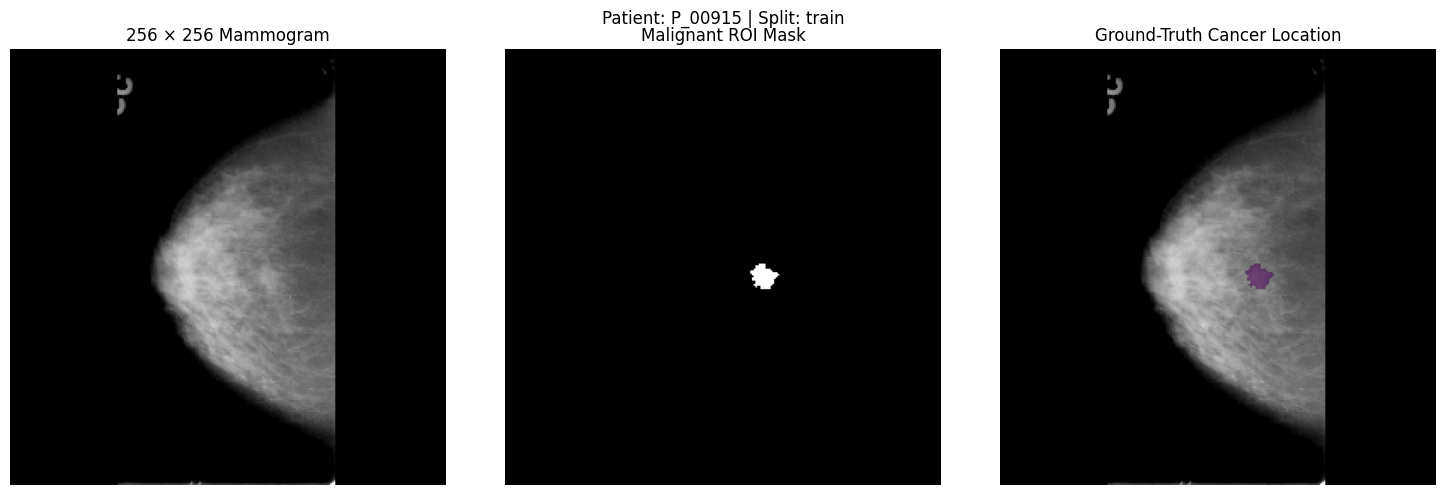

In [108]:
example = malignant_cases.sample(
    1,
    random_state=42
).iloc[0]

show_localization_case(
    example
)

In [109]:
#save the localization metadata
seg_df.to_csv(
    RESULTS_DIR/ "localization_dataset.csv",
    index=False
)

## 16. TensorFlow Data Input for Localization

#### This section converts the 256 x 256 mammograms and lesion masks into TensorFlow datasets for U-Net training and evaluation. The mammograms are normalized to a pixel range of 0-1, while the segmentation masks are converted into binary values of 0 for background and 1 for malignant lesion. 

In [110]:
#keep only the localization cases assigned to the training split 
seg_train = seg_df[
    seg_df["split"] == "train"
].reset_index(drop=True)

#keep only localization cases assigned to the validation split 
seg_val = seg_df[
    seg_df["split"] == "validation"
].reset_index(drop=True)

#keep only localization cases assigned to the test split 
seg_test = seg_df[
    seg_df["split"] == "test"
].reset_index(drop=True)

#displays the number of training/validation/test mammograms 
print("Train:", len(seg_train))
print("Validation:", len(seg_val))
print("Test:", len(seg_test))

Train: 982
Validation: 249
Test: 361


In [111]:
#extract image and mask paths 
seg_train_images = ( #get the prepared 256 x 256 training mammogram paths 
    seg_train["localization_image"] #select the image-path column 
    .astype(str) #ensures every path is a string 
    .values #converts the pandas Series to a NumPy array
)

#get the corresponding training mask paths 
seg_train_masks = (
    seg_train["localization_mask"]
    .astype(str)
    .values
)

#get the validation mammogram paths 
seg_val_images = (
    seg_val["localization_image"]
    .astype(str)
    .values
)

#get the corresponding validation mask paths 
seg_val_masks = (
    seg_val["localization_mask"]
    .astype(str)
    .values
)

#get the test mammogram paths
seg_test_images = (
    seg_test["localization_image"]
    .astype(str)
    .values
)

#get the corresponding test mask paths 
seg_test_masks = (
    seg_test["localization_mask"]
    .astype(str)
    .values
)

In [112]:
#define how TensorFlow loads one image-mask pair 
SEG_SIZE = LOCALIZATION_SIZE #segmentation image height and width 
SEG_BATCH_SIZE = 8 #number of image-mask pairs processed together 

#definition of how TensorFlow should load one mammogram and its mask 
def load_segmentation_pair(image_path, mask_path):
    
    #reads the mammogram PNG file from the disk 
    image = tf.io.read_file(image_path)

    #decode the mammogram as a one-channel grayscale image
    image = tf.image.decode_png(image, channels=1)

    #converts the mammogram to float 32 and normalize pixels from 0-255 to 0-1 
    image = tf.cast(image, tf.float32) / 255.0

    #reads the ground-truth segmentation mask from disk 
    mask = tf.io.read_file(mask_path)

    #decodes the mask as a one-channel grayscale image
    mask = tf.image.decode_png(mask, channels=1)

    #converts the saved 0/255 mask into a binary mask containing only 0.0 and 1.0
    mask = tf.cast(mask > 127, tf.float32)

    #tells TensorFlow that every mask has shape 256 x 256  x 1 
    image.set_shape([SEG_SIZE, SEG_SIZE, 1])

    mask.set_shape([SEG_SIZE, SEG_SIZE, 1])

    return image, mask

In [113]:
#create the segmentation training dataset
#starts a TensorFlow Dataset pipeline
#pair every training mammogram path with its corresponding mask path 
seg_train_ds = tf.data.Dataset.from_tensor_slices((seg_train_images, seg_train_masks))

#randomize the training examples 
seg_train_ds = seg_train_ds.shuffle(
    len(seg_train), 
    seed=42
)

#load and prepare every training pair 
seg_train_ds = seg_train_ds.map(
    load_segmentation_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

#create training batches
seg_train_ds = seg_train_ds.batch(
    SEG_BATCH_SIZE
)

#prepare the next training batch 
seg_train_ds = seg_train_ds.prefetch(
    tf.data.AUTOTUNE
)

#pair each validation mammogram with its mask 
seg_val_ds = tf.data.Dataset.from_tensor_slices(
    (
        seg_val_images, 
        seg_val_masks
    )
)

#load and prepare every validation pair 
seg_val_ds = seg_val_ds.map(
    load_segmentation_pair, 
    num_parallel_calls=tf.data.AUTOTUNE
)

#create validation batches
seg_val_ds = seg_val_ds.batch(
    SEG_BATCH_SIZE
)

#prepare the next validation batch
seg_val_ds = seg_val_ds.prefetch(
    tf.data.AUTOTUNE
)

#pair each test mammogram with its maks 
seg_test_ds = tf.data.Dataset.from_tensor_slices(
    (
        seg_test_images, 
        seg_test_masks
    )
)

#load and prepare every test pair
seg_test_ds = seg_test_ds.map(
    load_segmentation_pair, 
    num_parallel_calls=tf.data.AUTOTUNE
)

#create test batches 
seg_test_ds = seg_test_ds.batch(
    SEG_BATCH_SIZE
)

#prepare the next test batch 
seg_test_ds = seg_test_ds.prefetch(
    tf.data.AUTOTUNE
)

In [114]:
#take only the first batch from the training dataset
for images, masks in seg_train_ds.take(1):
    #display the dimensions of the mammogram batch 
    print("Image batch:", images.shape)

    #dimensions of the corresponding mask batch
    print("Mask batch:", masks.shape)

    #min and max mammogram pixel values 
    print("Image range:", images.numpy().min(), "-", images.numpy().max())

    #unique value found in the target masks 
    print("Mask values:", np.unique(masks.numpy()))

Image batch: (8, 256, 256, 1)
Mask batch: (8, 256, 256, 1)
Image range: 0.0 - 1.0
Mask values: [0. 1.]


## 17. U-Net Malignant Lesion Localization

#### The original U-Net paper containes a contracting path to capture context and an expanding path for precise localization. TensorFlow's official segmentation tutorial also explains U-Net in terms of encoder/decorder and decoder/upsampler. 

In [115]:
#dice coefficient
def dice_coefficient(y_true, y_pred, smooth=1e-6): #dice coefficient used to measure overlap between the true and predicted lesion masks 

    y_true = tf.cast( #ensure the true masks are floating-point tensors
        y_true,
        tf.float32
    )

    y_pred = tf.cast( #ensure the predicted masks are tensors 
        y_pred,
        tf.float32
    )

    intersection = tf.reduce_sum( #calculate the overlap between the true mask and predicted mask for each image 
        y_true * y_pred,
        axis=(1, 2, 3)
    )

    denominator = ( #calculate the total amount of true-mask and predicted mask activation 
        tf.reduce_sum(y_true, axis=(1, 2, 3)) +
        tf.reduce_sum(y_pred, axis=(1, 2, 3))
    )

    #calculate dice score for each image 
    dice = (2.0 * intersection + smooth) / (denominator + smooth)

    return tf.reduce_mean(dice)

In [116]:
#combined Binary Cross-Entropy + Dice loss 
def dice_bce_loss(y_true, y_pred): 

    bce = tf.keras.losses.binary_crossentropy( #calculates binary cross-entropy between the true and predicted value of every pixel 
        y_true,
        y_pred
    )

    bce = tf.reduce_mean(bce) #average binary cross-entropy across the pixels/batch 

    #convert dice coefficient into a loss 
    dice_loss = (1.0 - dice_coefficient(y_true, y_pred))

    return bce + dice_loss

In [117]:
#reusable convolution block 
def conv_block(x, filters):
    
    #feature map currently moving through the network
    x = layers.Conv2D( #applies the first 3 x 3 confolution 
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.Conv2D( #applies the second 3 x 3 convolution 
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    return x

In [118]:
#build the U-Net 
def build_localization_unet():

    #one 256 x 256 grayscale mammogram
    inputs = keras.Input(shape=(SEG_SIZE, SEG_SIZE,1))

    #Encoder: reduce spatial size while also increasing the compelx features 
    c1 = conv_block(inputs, 16)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    c2 = conv_block(p1, 32)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    c3 = conv_block(p2, 64)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    #Bottleneck: deepest part of the network 
    bottleneck = conv_block(p3, 128)
    bottleneck = layers.Dropout(0.30)(bottleneck)

    #Decoder: reconstruct the spatial segmentation map 
    u3 = layers.UpSampling2D((2, 2))(bottleneck)
    u3 = layers.Concatenate()([u3, c3])
    c4 = conv_block(u3, 64)
    u2 = layers.UpSampling2D((2, 2))(c4)
    u2 = layers.Concatenate()([u2, c2])
    c5 = conv_block(u2, 32)
    #doubles the spatial dimensions 
    u1 = layers.UpSampling2D((2, 2))(c5)
    u1 = layers.Concatenate()([u1, c1])
    c6 = conv_block(u1, 16)

    #Final layer: Probability of malignant lesion for every pixel
    outputs = layers.Conv2D(
        1,
        1,
        activation="sigmoid"
    )(c6)

    #creates the complete U-Net model 
    model = keras.Model(
        inputs,
        outputs,
        name="malignant_localization_unet"
    )

    return model

In [119]:
#creates the U-Net 
localization_model = (build_localization_unet())

localization_model.summary() #displays the model's layers, output shapes and parameter counts 

Model: "malignant_localization_unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 256, 256,  │        160 │ input_layer_4[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 256, 256,  │      2,320 │ conv2d_12[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 128, 128,  │          0 │ conv2d_13[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 128, 128,  │      4,640 │ max_pooling2d_12… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_14[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 64, 64,    │          0 │ conv2d_15[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_13… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_16[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 32, 32,    │          0 │ conv2d_17[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_14… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_18[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_19[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ dropout_5[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 64, 64,    │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_20[0][0] 

 Total params: 487,009 (1.86 MB)

 Trainable params: 487,009 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [120]:
#compile the U-Net 
localization_model.compile( 
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_bce_loss, #train using the combined BCE + dice loss 
    metrics=[ #monitor dice overlap during training and validation 
        dice_coefficient
    ]
)

## 18. U-Net Training

In [121]:
#save the best U-Net during training 
localization_checkpoint = (
    keras.callbacks.ModelCheckpoint(MODELS_DIR / "malignant_localization_best.keras",
        monitor="val_loss", #monitors the validation loss after each epoch 
        mode="min", #lowers validation loss is considered better 
        save_best_only=True, #saves only when validation loss improves 
        verbose=1
    )
)

In [122]:
#callback to stop training when validation performance stops improving 
localization_early_stopping = (
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
)

In [123]:
#train the U-Net 
LOCALIZATION_EPOCHS = 30

history_localization = (
    localization_model.fit( #starts model training 
        seg_train_ds, #uses the segmentation training dataset
        validation_data=seg_val_ds, #evaluate on the validation dataset after every training epoch 
        epochs=LOCALIZATION_EPOCHS, #allows training for up to 30 epochs 
        callbacks=[ #use checkpointing and early stopping during the training 
            localization_checkpoint,
            localization_early_stopping
        ]
    )
)


Epoch 1/30


/opt/homebrew/Cellar/jupyterlab/4.3.4_1/libexec/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coefficient: 0.0020 - loss: 1.1937  
Epoch 1: val_loss improved from None to 1.00558, saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/models/malignant_localization_best.keras

Epoch 1: finished saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/models/malignant_localization_best.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - dice_coefficient: 0.0020 - loss: 1.1937 - val_dice_coefficient: 0.0113 - val_loss: 1.0056
Epoch 2/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coefficient: 0.0097 - loss: 1.0049  
Epoch 2: val_loss improved from 1.00558 to 1.00193, saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/models/malignant_localization_best.keras

Epoch 2: finished saving model to /Users/aliyahfazal/Desktop/breast-cancer-cnn/models/malignant_localization_best.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - dice_coefficient: 0.0097 - loss: 1.0049 - val_dice_coefficient: 0.0153 - val_loss: 1.0019
Epoch 

## 19. Localization Validation Check 

#### This section creates the probability masks for the localization validation set and check that the U-Net output has the anticipated dimensions and probability range. 

In [124]:
val_predictions = localization_model.predict( #generate probability masks for all validation mammograms 
    seg_val_ds
)

print("Prediction shape:", val_predictions.shape) #checks the prediction tensor dimensions 
#checks the min and max predicted probabilities
print("Probability range:", val_predictions.min(), "-", val_predictions.max())

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 441ms/step
Prediction shape: (249, 256, 256, 1)
Probability range: 0.0 - 0.99894464


In [125]:
#collect validation images and masks into arrays
val_images = []
val_masks = []

for images, masks in seg_val_ds: #go through every validation batch
    #convert the TensorFlow mammogram batch into a NumPy array 
    val_images.append(images.numpy())
    val_masks.append(masks.numpy())
#join all image/mask batched into one validation array 
val_images = np.concatenate(
    val_images,
    axis=0
)
val_masks = np.concatenate(
    val_masks,
    axis=0
)

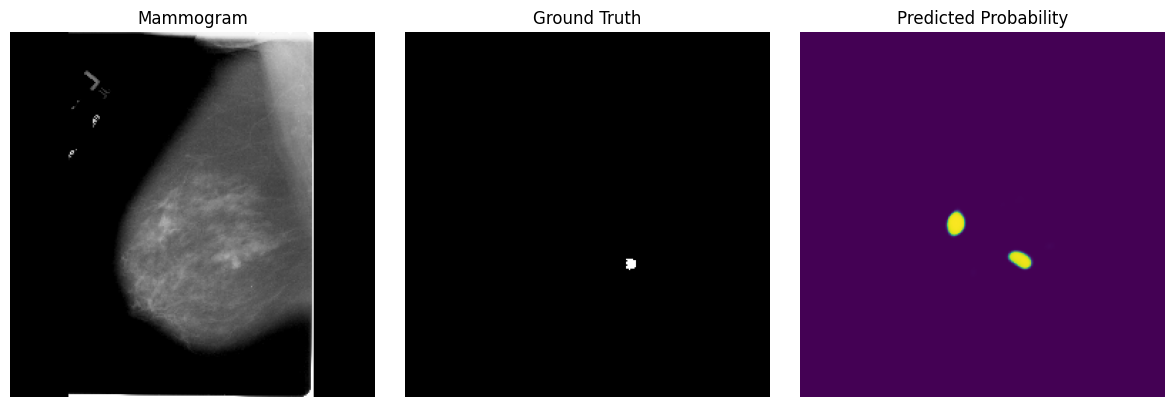

In [154]:
# Shows 1 malignant validation examples

malignant_index = np.where( #find validation cases that contain a malignant lesion 
    seg_val["has_malignant"].values == 1
)[0][0]

#get the selected mammogram 
image = val_images[malignant_index].squeeze()

#get its true malignant-lesion mask 
true_mask = val_masks[malignant_index].squeeze()

#get the U-Net's predicted probability map 
probability_mask = val_predictions[malignant_index].squeeze()

#visually inspect the validation prediction.
fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4)
)

axes[0].imshow(
    image,
    cmap="gray"
)
axes[0].set_title(
    "Mammogram"
)

axes[1].imshow(
    true_mask,
    cmap="gray"
)
axes[1].set_title(
    "Ground Truth"
)

axes[2].imshow(
    probability_mask,
    vmin=0,
    vmax=1
)
axes[2].set_title(
    "Predicted Probability"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 22. Localization Threshold Selection

#### The U-Net produces a probability of malignancy for every pixel, so a probability threshold is required to convert each probability map into a binary lesion mask. 

In [127]:
def binary_dice(true_mask, pred_mask, smooth=1e-6): #calculates Dice overlap between two binary masks 

    intersection = np.sum( #count the pixels that are positive in both the true and predicted masks 
        true_mask * pred_mask
    )

    #calculate binary Dice
    return (2 * intersection + smooth) / (np.sum(true_mask) + np.sum(pred_mask) + smooth)


def binary_iou(true_mask, pred_mask, smooth=1e-6): #calculate intersection over union between the true and predicted binary masks 

    intersection = np.sum( #count pixels that are positive in both masks 
        true_mask * pred_mask
    )

    union = np.sum( #count pixels that are positive in either the true mask or predicted mask 
        (true_mask + pred_mask) > 0
    )

    return ( #calculate IoU
        intersection + smooth) / (
        union + smooth
    )

In [131]:
threshold_candidates = [
    0.30, 
    0.40, 
    0.50, 
    0.60, 
    0.70
] 

malignant_indices = np.where( #find the indices of validation mammograms that contain a malignant target 
    seg_val["has_malignant"].values == 1
)[0]

benign_indices = np.where( #find the indices of validation mammograms that contain no malignant target 
    seg_val["has_malignant"].values == 0
)[0]

threshold_results = [] 
for threshold in threshold_candidates: #tests possible probability thresholds 
    dice_scores = [] 
    iou_scores = []

    for idx in malignant_indices: #evaluate overlap only on malignant validation cases 

        true_mask = ( #gets the true binary lesion mask for this validation mammogram 
            val_masks[idx]
            .squeeze()
            .astype(np.uint8)
        )

        predicted_mask = ( #convert the predicted probability mask into a binary mask using the current threshold 
            val_predictions[idx]
            .squeeze()
            >= threshold
        ).astype(np.uint8)

        dice_scores.append( #calculate and store Dice for this case 
            binary_dice(true_mask, predicted_mask)
        )

        iou_scores.append( #calculate and store IoU for this case 
            binary_iou(true_mask, predicted_mask)
        )


    non_malignant_false_positives = 0 #starts a counter for non-malignant mammograms 

    for idx in benign_indices: #examine every non-malignant validation mammogram

        predicted_mask = ( #convert its predicted probability map into a binary mask using the same threshold 
            val_predictions[idx]
            .squeeze()
            >= threshold
        )

        if np.any(predicted_mask): #check whether the model predicted any positive lesion pixel at all 
            non_malignant_false_positives += 1  #count this mammogram as a false positive 

    non_malignant_false_positive_rate = (non_malignant_false_positives / len(benign_indices))
    
    threshold_results.append( #stores the summary statistics for this threshold 
        {
            "Threshold": threshold,
            "Mean malignant Dice": np.mean(dice_scores),
            "Mean malignant IoU": np.mean(iou_scores),
            "Benign false-positive rate": non_malignant_false_positive_rate
        })


threshold_df = pd.DataFrame( #converts all threshold results into a DataFrame
    threshold_results
)

threshold_df.round(4)

,Threshold,Mean malignant Dice,Mean malignant IoU,Benign false-positive rate
0,0.3,0.4448,0.3290,0.8333
1,0.4,0.4430,0.3280,0.8333
2,0.5,0.4408,0.3267,0.8333
3,0.6,0.4381,0.3248,0.8175
4,0.7,0.4333,0.3207,0.8175


In [132]:
best_index = threshold_df[ #finds the row containing the highest mean malignant validation Dice score 
        "Mean malignant Dice"].idxmax()


best_row = threshold_df.loc[
    best_index
]

LOCALIZATION_THRESHOLD = float( #Extract that row's threshold and convert it to a normal Python float 
    best_row["Threshold"]
)

print( #display the selected threshold 
    "Selected LOCALIZATION threshold:",
    LOCALIZATION_THRESHOLD
)

print(best_row) #display all validation metrics 

Selected LOCALIZATION threshold: 0.3
Threshold                     0.300000
Mean malignant Dice           0.444806
Mean malignant IoU            0.328978
Benign false-positive rate    0.833333
Name: 0, dtype: float64


## 21. Final Localization Test Evaluation

#### This section evaluates the trained U-Net on the localization test set using the probability threshold selected from the validation set. 

In [133]:
#generate test predictions and collect test arrays 
#run the trained U-Net one very test mammogram and store the probability masks 
test_predictions = localization_model.predict(seg_test_ds)

test_images = []
test_masks = []

for images, masks in seg_test_ds: #go through every batch in the test dataset
    #add this batch of mammograms
    test_images.append( 
        images.numpy()
    )
    #add this batch of true masks
    test_masks.append( 
        masks.numpy()
    )

test_images = np.concatenate( #join all image batches into one array 
    test_images,
    axis=0
)

test_masks = np.concatenate( #join all 
    test_masks,
    axis=0
)

#check that predictions and true masks have matching dimensions 
print(
    "Test prediction shape:",
    test_predictions.shape
)

print(
    "True test mask shape:",
    test_masks.shape
)

46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 437ms/step
Test prediction shape: (361, 256, 256, 1)
True test mask shape: (361, 256, 256, 1)


In [134]:
#converts probability maps into binary masks using the frozen threshold 
test_pred_binary = (
    test_predictions
    >= LOCALIZATION_THRESHOLD
).astype(np.uint8)

In [135]:
#find the test mammograms containing malignant lesions 
malignant_test_indices = np.where(
    seg_test["has_malignant"].values == 1
)[0]

test_dice_scores = []
test_iou_scores = []

#calculate Dice and IoU for every malignant test mammogram
for idx in malignant_test_indices:
    
    #get the true binary lesion mask 
    true_mask = (test_masks[idx].squeeze().astype(np.uint8))
    
    #get the predicted binary lesion mask 
    pred_mask = (test_pred_binary[idx].squeeze().astype(np.uint8) )

    #calculates and stores Dice overlap
    test_dice_scores.append(binary_dice(true_mask, pred_mask))

    #calculate and store IoU overlap
    test_iou_scores.append(binary_iou(true_mask, pred_mask))

#summary results for malignant test cases 
mean_test_dice = np.mean(test_dice_scores)
median_test_dice = np.median(test_dice_scores)
mean_test_iou = np.mean(test_iou_scores)
median_test_iou = np.median(test_iou_scores)

print(
    "Malignant test cases:",
    len(malignant_test_indices)
)

print(
    "Mean malignant test Dice:",
    mean_test_dice
)

print(
    "Median malignant test Dice:",
    median_test_dice
)

print(
    "Mean malignant test IoU:",
    mean_test_iou
)

print(
    "Median malignant test IoU:",
    median_test_iou
)

Malignant test cases: 145
Mean malignant test Dice: 0.42679296721546506
Median malignant test Dice: 0.45777777898271604
Mean malignant test IoU: 0.3229352384441557
Median malignant test IoU: 0.29682997320798277


In [138]:
#find the test mammograms without malignant lesions 
benign_test_indices =  np.where(
    seg_test["has_malignant"].values == 0
)[0]

#count benign mammograms where any lesion was predicted
benign_false_positives = 0


for idx in benign_test_indices:
    #count predicted malignant pixels in this mammogram
    predicted_pixels = np.sum(
        test_pred_binary[idx] > 0
    )

    #any predicted lesion makes this a false-positive case
    if predicted_pixels > 0:
        benign_false_positives += 1

#calculate the benign false-positive rate
benign_fp_rate = (benign_false_positives/len(benign_test_indices))

#display the benign test results 
print(
    "Benign test cases:",
    len(benign_test_indices)
)

print(
    "Benign cases with predicted lesion:", benign_false_positives, "/",
    len(benign_test_indices)
)

print(
    "Benign false-positive rate:",
    benign_fp_rate
)

Benign test cases: 216
Benign cases with predicted lesion: 193 / 216
Benign false-positive rate: 0.8935185185185185


In [139]:
#final test-results table
localization_test_results = pd.DataFrame(
    {
        "Metric": [
            "Threshold",
            "Mean malignant Dice",
            "Median malignant Dice",
            "Mean malignant IoU",
            "Median malignant IoU",
            "Benign false-positive rate"
        ],

        "Value": [
            LOCALIZATION_THRESHOLD,
            np.mean(test_dice_scores),
            np.median(test_dice_scores),
            np.mean(test_iou_scores),
            np.median(test_iou_scores),
            benign_fp_rate
        ]
    }
)

#display the final results 
localization_test_results

,Metric,Value
0,Threshold,0.300000
1,Mean malignant Dice,0.426793
2,Median malignant Dice,0.457778
3,Mean malignant IoU,0.322935
4,Median malignant IoU,0.296830
5,Benign false-positive rate,0.893519


In [140]:
#save the final localization test results
localization_test_results.to_csv(
    RESULTS_DIR/"localization_test_results.csv",
    index=False
)

## 22. Final Localization Examples

In [141]:
#creates a case -evel results table for malignant test mammograms
localization_case_results = pd.DataFrame({
    "test_index": malignant_test_indices,
    "dice": test_dice_scores,
    "iou": test_iou_scores
})

#rank the malignant test cases from highest to lowest Dice
localization_case_results = (
    localization_case_results
    .sort_values("dice", ascending=False)
    .reset_index(drop=True)
)

In [142]:
localization_case_results.to_csv(
    RESULTS_DIR
    / "localization_case_results.csv",
    index=False
)

In [143]:
#select the highest, middle, and lowest Dice cases 
selected_examples = localization_case_results.iloc[
    [0, len(localization_case_results) // 2, -1]].copy()


#names for each example
selected_examples["example_name"] = [
    "Strong localization", 
    "Typical LOCALIZATION", 
    "Weak LOCALIZATION"
]

selected_examples = selected_examples.reset_index(drop=True)

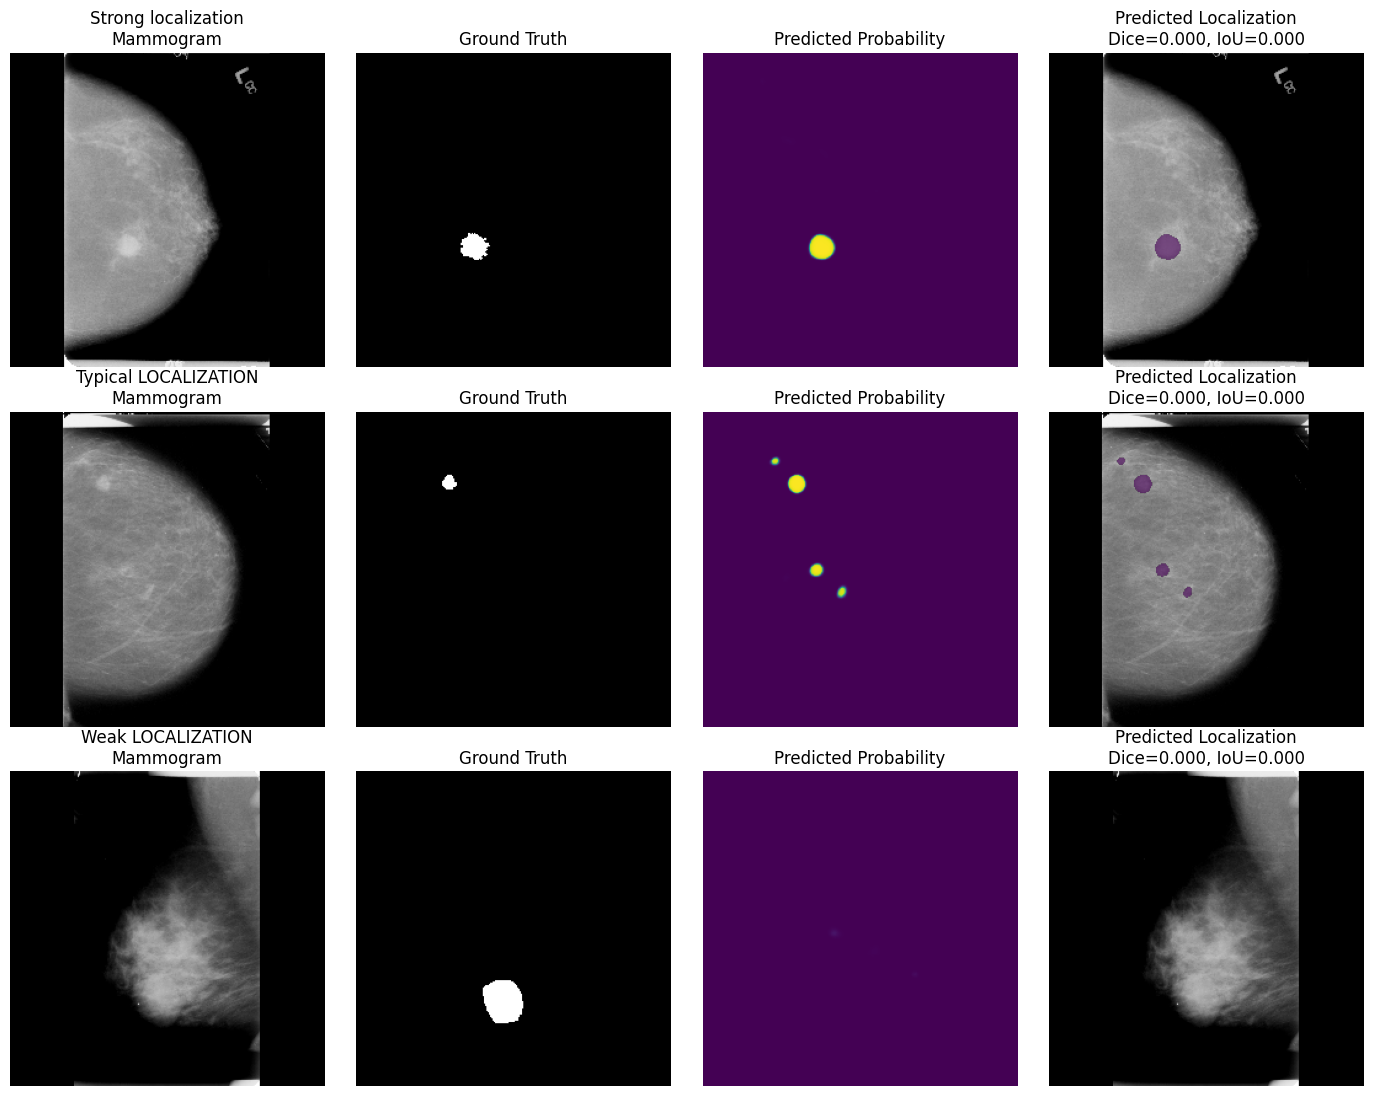

In [153]:
fig, axes = plt.subplots(
    3,
    4,
    figsize=(14, 11)
)

for row_num in range (
    len(selected_examples)
):
    #get information for the current example 
    row = selected_examples.iloc[row_num]

    #get the test-set position of this mammogram
    idx = int(row["test_index"])

    #get the example name 
    example_name = row["example_name"]

    #get the dice and IoU values
    dice_values = row["dice"]
    iou_values = row["iou"]

    #get the prepared mammogram 
    image = test_images[idx].squeeze()

    #get the true malignant lesion mask 
    true_mask = test_masks[idx].squeeze()

    #get the U-Net's probability map 
    probability_map = test_predictions[idx].squeeze()

    #convert the probability map into a binary lesion mask 
    predicted_mask = (probability_map >= LOCALIZATION_THRESHOLD)

    #hide background pixels for the prediction overlay 
    visible_prediction = np.ma.masked_where(predicted_mask == 0, predicted_mask)

    #column 1: mammogram 
    axes[row_num, 0].imshow(image, cmap="gray")
    axes[row_num, 0].set_title(f"{example_name}\nMammogram")

    #column 2: true malignant-lesion mask 
    axes[row_num, 1].imshow(true_mask, cmap="gray")
    axes[row_num, 1].set_title("Ground Truth")

    #column 3: U-Net probability map 
    axes[row_num, 2].imshow(probability_map, vmin=0, vmax=1)
    axes[row_num, 2].set_title("Predicted Probability")

    #column 4: predicted lesion overlaid on the mammogram 
    axes[row_num, 3].imshow(image, cmap="gray")
    axes[row_num, 3].imshow(visible_prediction, alpha=0.65)
    axes[row_num, 3].set_title(
        f"Predicted Localization\n"
        f"Dice={dice_value:.3f}, "
        f"IoU={iou_value:.3f}"
    )

    #remove axis numbers from all four panels 
    for ax in axes[row_num]:
        ax.axis("off")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "localization_test_examples.png", 
    dpi=300, 
    bbox_inches="tight"
)
plt.show()